# Preparation (Run directly)

In [5]:
import sys

import numpy as np
import pandas as pd
import arviz as az

from math import sqrt

from collections import defaultdict

from scipy.stats import truncnorm, norm, truncexpon
from scipy.linalg import inv, cholesky
from scipy.optimize import linprog
import scipy.interpolate as si

from sklearn.metrics import accuracy_score
from sklearn.svm import LinearSVC

from statsmodels.tsa.stattools import acf
from statsmodels.graphics.tsaplots import plot_acf

import os
import pickle
import pyreadr

import networkx as nx

from joblib import Parallel, delayed 
from tqdm import tqdm

import matplotlib.pyplot as plt
import seaborn as sns


In [29]:
#  MCMCAnalysis class 

class MCMCAnalysis:
    def __init__(self, samples, burn_in=0, param_name=None, ground_truth=None):
        """
        Initialize the MCMCAnalysis class.

        Parameters:
        ----------
        samples : numpy.ndarray
            MCMC samples of shape (n_iterations, dim1, dim2), where:
            - n_iterations: Number of MCMC iterations.
            - dim1: First dimension (e.g., response dimensions).
            - dim2: Second dimension (e.g., predictors or parameters).
        burn_in : int, optional
            Number of initial iterations to discard as burn-in (default is 0).
        param_name : str, optional
            Name of the parameter being analyzed (e.g., "beta", "zeta", "u"). Default is None.
        """
        # Validate input dimensions
        if not isinstance(samples, np.ndarray):
            raise ValueError("Samples must be a numpy array.")
        if samples.ndim != 3:
            raise ValueError("Samples must have three dimensions: (n_iterations, dim1, dim2).")

        # Store raw samples and post burn-in samples
        self.raw_samples = samples  # All samples including burn-in
        self.burn_in = burn_in
        if burn_in >= samples.shape[0]:
            raise ValueError("Burn-in must be less than the number of iterations.")
        self.samples = samples[burn_in:]  # Post burn-in samples

        # Store dimensions
        self.n_iterations, self.dim1, self.dim2 = self.samples.shape

        # Store parameter name
        self.param_name = param_name if param_name else "Parameter"

        # Store ground truth if available
        self.ground_truth = ground_truth

        # Print initialization details
        print(f"Initialized MCMCAnalysis for {self.param_name}:")
        print(f"- Total iterations: {samples.shape[0]}")
        print(f"- Burn-in: {burn_in}")
        print(f"- Post burn-in iterations: {self.n_iterations}")
        print(f"- Dimension 1 (dim1): {self.dim1}")
        print(f"- Dimension 2 (dim2): {self.dim2}")




    



    def posterior_means(self):
        """
        Compute the posterior mean of each parameter.

        Returns:
        -------
        posterior_means : numpy.ndarray
            Posterior mean of shape (dim1, dim2).
        """
        return np.mean(self.samples, axis=0)
    


    def MSE(self):
        """
        Compute the Mean Squared Error (MSE) between the posterior means and the ground truth.

        Parameters:
        ----------
        ground_truth : numpy.ndarray
            The ground truth parameter values of shape (dim1, dim2).

        Returns:
        -------
        mse : float
            The Mean Squared Error between the posterior means and the ground truth.
        """
        if self.ground_truth is None:
            raise ValueError("Ground truth is required to compute MSE.")
        
        posterior_means = self.posterior_means()

        # Validate dimensions
        if self.ground_truth.shape != posterior_means.shape:
            raise ValueError(
                f"Dimension mismatch: ground_truth has shape {self.ground_truth.shape}, "
                f"but posterior means have shape {posterior_means.shape}."
            )

        # Compute MSE
        mse = np.mean((posterior_means - self.ground_truth) ** 2)
        return mse
    


    def gelman_rubin(self):
        """
        Compute the Gelman-Rubin diagnostic (R-hat) for convergence assessment.

        Returns:
        -------
        rhat_values : numpy.ndarray
            R-hat values for each parameter of shape (dim1, dim2).
        """
        rhat_values = np.zeros((self.dim1, self.dim2))
        for i in range(self.dim1):
            for j in range(self.dim2):
                rhat_values[i, j] = az.rhat(self.samples[:, i, j])
        return rhat_values



    def posterior_distributions(self, bins=30):
        """
        Plot the posterior distributions for all parameters.

        Parameters:
        ----------
        bins : int, optional
            Number of bins for the histogram (default is 30).
        """
        fig, axes = plt.subplots(self.dim1, self.dim2, figsize=(15, 5 * self.dim1), sharex=False, sharey=False)

        if self.dim2 == 1:
            axes = np.expand_dims(axes, axis=-1)
        if self.dim1 == 1:
            axes = np.expand_dims(axes, axis=0)

        fig.suptitle(f"Posterior Distributions of {self.param_name} Samples", fontsize=16)

        for i in range(self.dim1):
            for j in range(self.dim2):
                ax = axes[i, j] if (self.dim1 > 1 and self.dim2 > 1) else axes[max(i, j)]
                ax.hist(self.samples[:, i, j], bins=bins, alpha=0.7, label=f"{self.param_name}[{i},{j}]")
                ax.set_title(f"{self.param_name}[{i},{j}]", fontsize=12)
                ax.set_xlabel("Value", fontsize=10)
                ax.set_ylabel("Frequency", fontsize=10)
                ax.legend()

        plt.tight_layout(rect=[0, 0, 1, 0.95])
        plt.show()


    
    def effective_sample_size(self):
        """
        Compute the effective sample size (ESS) for each parameter.

        Returns:
        -------
        ess_values : numpy.ndarray
            Effective sample size for each parameter of shape (dim1, dim2).
        """
        ess_values = np.zeros((self.dim1, self.dim2))
        for i in range(self.dim1):
            for j in range(self.dim2):
                ess_values[i, j] = az.ess(self.samples[:, i, j])
        return ess_values
    




    def plot_trace_single_param(self, idx, plot_ground_truth=True, save_path=None):
        """
        Plot the trace plot for a single parameter.

        Parameters:
        ----------
        idx : tuple
            Index of the parameter to plot (dim1, dim2).
        ground_truth : numpy.ndarray, optional
            Ground truth value of the parameter at the specified index. If provided, a horizontal line is plotted.
        save_path : str, optional
            Path to save the plot as an image file (e.g., "trace_plot.png"). If None, the plot is displayed.
        """
        if not isinstance(idx, tuple) or len(idx) != 2:
            raise ValueError("Index must be a tuple of (dim1, dim2).")

        dim1, dim2 = idx
        plt.figure(figsize=(12, 6))
        plt.plot(range(self.n_iterations), self.samples[:, dim1, dim2], alpha=0.8)
        # Add a horizontal line afor the ground truth if available
        if plot_ground_truth and self.ground_truth is not None:
            plt.axhline(self.ground_truth[dim1, dim2], color='red', linestyle='--', label="Ground Truth")

        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            print(f"Plot saved to {save_path}")
        else:
            plt.show()





    def trace_plots(self, max_dim1=10, max_dim2=10, config=1, param_indices=[(0, 0)], 
                    save_path=None, clean_mode=False):
        """
        Plot the trace plots for all parameters.

        Parameters:
        ----------
        max_dim1 : int, optional
            Maximum number of plots for the first dimension (default is 10).
        max_dim2 : int, optional
            Maximum number of plots for the second dimension (default is 10).
        config : int, optional
            Config 1: Individual trace plots for each parameter.
            Config 2: Single plot with all traces of selected parameters.
        param_indices : list of tuples, optional (for config==2)
            List of (dim1, dim2) index pairs specifying which parameters to plot (default is [(0,0)]).
        ground_truth : np.ndarray, optional
            Ground truth values of shape (dim1, dim2). If provided, a vertical line is plotted at the ground truth.
        save_path : str, optional
            Path to save the plot as an image file (e.g., "trace_plots.png"). If None, the plot is displayed.
        clean_mode : bool, optional
            If True, the plot is generated without titles and axis labels but keeps the legend (default is False).
        """
        ground_truth = self.ground_truth
        if ground_truth is None:
            print("Warning: Ground truth is not provided. Ground truth lines will not be plotted.")

        if config == 1:
            # Determine dimensions to plot
            plot_dim1 = min(self.dim1, max_dim1)
            plot_dim2 = min(self.dim2, max_dim2)

            # Create subplots
            if plot_dim2 == 1:
                fig, axes = plt.subplots(plot_dim1, 1, figsize=(15, 5 * plot_dim1), sharex=True, sharey=False)
                axes = np.atleast_1d(axes)  # Ensure axes is iterable
            else:
                fig, axes = plt.subplots(plot_dim1, plot_dim2, figsize=(15, 5 * plot_dim1), sharex=True, sharey=False)

            if not clean_mode:
                fig.suptitle(f"Trace Plots of {self.param_name} Samples (Truncated to {plot_dim1} x {plot_dim2})", fontsize=16)

            # Plot each trace plot
            for i in range(plot_dim1):
                for j in range(plot_dim2):
                    ax = axes[i] if plot_dim2 == 1 else axes[i, j]
                    ax.plot(range(self.n_iterations), self.samples[:, i, j], label=f"{self.param_name}[{i},{j}]", alpha=0.8)

                    # Plot ground truth if available
                    if ground_truth is not None:
                        ax.axhline(ground_truth[i, j], color='red', linestyle='--', label="Ground Truth")

                    # Keep legends but remove axis labels & titles if clean_mode=True
                    if not clean_mode:
                        ax.set_title(f"{self.param_name}[{i},{j}]", fontsize=12)
                        ax.set_xlabel("Iteration", fontsize=10)
                        ax.set_ylabel("Value", fontsize=10)
                    ax.legend()

            # Adjust layout
            plt.tight_layout(rect=[0, 0, 1, 0.95])
            if save_path:
                plt.savefig(save_path, dpi=300)
                print(f"Plot saved to {save_path}")
            else:
                plt.show()

            # Warn the user if dimensions were truncated
            if self.dim1 > max_dim1 or self.dim2 > max_dim2 and not clean_mode:
                print(f"Warning: Dimensions truncated for plotting. Only the first {max_dim1} x {max_dim2} parameters are shown.")

        elif config == 2:
            # Ensure param_indices is a valid list
            if param_indices is None:
                param_indices = [(0, 0)]  # Default value
            elif not isinstance(param_indices, list) or not all(isinstance(t, tuple) and len(t) == 2 for t in param_indices):
                raise ValueError("param_indices must be a list of (dim1, dim2) tuples.")

            # Create figure
            plt.figure(figsize=(5, 5))

            # Plot traces of all selected parameters in one plot
            for idx, (i, j) in enumerate(param_indices):
                plt.plot(range(self.n_iterations), self.samples[:, i, j], label=f"{self.param_name}[{i},{j}]", color='black')

                # Plot ground truth if available
                if ground_truth is not None:
                    if len(param_indices) > 1:
                        plt.axhline(ground_truth[i, j], linestyle='--', color=f"C{idx}", label=f"GT {self.param_name}[{i},{j}]")
                    else:
                        plt.axhline(ground_truth[i, j], linestyle='--', color='red', label="Ground Truth")

            # Keep legend but remove axis labels & title if clean_mode=True
            if not clean_mode:
                plt.title(f"Trace Plots of Selected {self.param_name} Samples", fontsize=16)
                plt.xlabel("Iteration", fontsize=12)
                plt.ylabel("Value", fontsize=12)
                plt.legend()
            
            plt.xticks(fontsize=20, ticks=[0,self.n_iterations//2,self.n_iterations])
            plt.yticks(fontsize=20)

            plt.locator_params(axis='y', nbins=5)

            plt.tight_layout()
            if save_path:
                plt.savefig(save_path, dpi=300, bbox_inches='tight')
                print(f"Plot saved to {save_path}")
            else:
                plt.show()

 



    def plot_ACF(self, max_lag=50, config=2, thinning=10, save_path=None, clean_mode=False, tick_size=20):
        """
        Plot the autocorrelation function (ACF) for all parameters.

        Parameters:
        ----------
        max_lag : int, optional
            Maximum lag to compute the ACF (default is 50).
        thinning : int, optional
            Thinning factor for MCMC samples (default is 10).
        config : int, optional
            Config 1: Separate ACF plots for each parameter.
            Config 2: Single plot with ACF for all parameters stacked.
        save_path : str, optional
            Path to save the plot as an image file (e.g., "acf_plot.png"). If None, the plot is displayed.
        clean_mode : bool, optional
            If True, the plot is generated without titles and axis labels but keeps the legend (default is False).
        tick_size : int, optional
            Font size for x and y ticks (default is 20).
        """
        
        if config == 1:
            # Separate ACF plots for each parameter
            fig, axes = plt.subplots(self.dim1, self.dim2, figsize=(15, 5 * self.dim1), sharex=False, sharey=False)

            if self.dim2 == 1:
                axes = np.expand_dims(axes, axis=-1)
            if self.dim1 == 1:
                axes = np.expand_dims(axes, axis=0)

            if not clean_mode:
                fig.suptitle(f"Autocorrelation Function (ACF) of {self.param_name} Samples", fontsize=16)

            for i in range(self.dim1):
                for j in range(self.dim2):
                    ax = axes[i, j] if (self.dim1 > 1 and self.dim2 > 1) else axes[max(i, j)]
                    plot_acf(self.samples[::thinning, i, j], lags=max_lag, ax=ax, alpha=0.7)

                    # Remove titles & labels in clean mode but keep legend
                    if not clean_mode:
                        ax.set_title(f"{self.param_name}[{i},{j}]", fontsize=12)
                        ax.set_xlabel("Lag", fontsize=10)
                        ax.set_ylabel("ACF", fontsize=10)

            plt.tight_layout(rect=[0, 0, 1, 0.95])
            if save_path:
                plt.savefig(save_path, dpi=300)
                print(f"Plot saved to {save_path}")
            else:
                plt.show()

        elif config == 2:
            # Apply thinning
            thinned_samples = self.samples[::thinning, :, :]  # Shape: (n_iter/thinning, dim1, dim2)

            # Flatten the samples to shape (n_iter, dim1 * dim2)
            reshaped_samples = thinned_samples.reshape(thinned_samples.shape[0], -1)

            # Compute ACF values using statsmodels
            acf_values = np.zeros((max_lag + 1, reshaped_samples.shape[1]))  # Shape: (lags, parameters)
            for param_idx in range(reshaped_samples.shape[1]):
                acf_values[:, param_idx] = acf(reshaped_samples[:, param_idx], nlags=max_lag, fft=True)

            # Convert to DataFrame for seaborn plotting
            df = pd.DataFrame(acf_values, columns=[f"{self.param_name}[{i}]" for i in range(reshaped_samples.shape[1])])
            df["Lag"] = np.arange(max_lag + 1)
            df_long = df.melt(id_vars="Lag", var_name="Parameter Index", value_name="ACF")

            # Plot ACF for all parameters in a single plot using boxplots
            plt.figure(figsize=(9, 6))
            sns.boxplot(x="Lag", y="ACF", data=df_long, width=0.6, showfliers=False, fill=False, palette=['black'])
            plt.axhline(y=0, color='gray', linestyle='--', linewidth=1)

            # Set x-ticks at intervals of 5
            plt.xticks(ticks=np.arange(10, max_lag + 1, 10), fontsize=tick_size)
            plt.yticks(fontsize=tick_size)  

            # Remove labels in clean mode but keep legend
            if not clean_mode:
                plt.xlabel("Lag")
                plt.ylabel("Autocorrelation")
                plt.title(f"Autocorrelation Function (ACF) for {self.param_name} (Thinning={thinning})", fontsize=16)
            else:
                plt.xlabel(None)
                plt.ylabel(None)
                

            plt.tight_layout()
            if save_path:
                plt.savefig(save_path, dpi=300, bbox_inches='tight')
                print(f"Plot saved to {save_path}")
            else:
                plt.show()



    



    def plot_posterior_violin(self, config=3, save_path=None, clean_mode=False, tick_size=20):
        """
        Plot the posterior distributions of all parameters using violin plots.

        Parameters:
        ----------
        ground_truth : np.ndarray, optional
            Ground truth values of shape (dim1, dim2) for sorting the parameters.
        config : int, optional
            Configuration for plotting:
            - 1: Separate violin plots for each parameter.
            - 3: Single violin plot combining all parameters (unsorted).
        save_path : str, optional
            Path to save the plot as an image file (e.g., "posterior_violin.png"). If None, the plot is displayed.
        clean_mode : bool, optional
            If True, removes titles and axis labels but keeps the legend (default is False).
        tick_size : int, optional
            Font size for x and y ticks (default is 20).
        """
        ground_truth = self.ground_truth
        if ground_truth is None:
            print("Warning: Ground truth is not provided. Ground truth lines will not be plotted.")

        if config == 1:
            fig, axes = plt.subplots(self.dim1, self.dim2, figsize=(15, 5 * self.dim1), sharex=False, sharey=False)

            if self.dim2 == 1:
                axes = np.expand_dims(axes, axis=-1)
            if self.dim1 == 1:
                axes = np.expand_dims(axes, axis=0)

            if not clean_mode:
                fig.suptitle(f"Posterior Distributions of {self.param_name} Samples (Violin Plots)", fontsize=16)

            for i in range(self.dim1):
                for j in range(self.dim2):
                    ax = axes[i, j] if (self.dim1 > 1 and self.dim2 > 1) else axes[max(i, j)]
                    sns.violinplot(y=self.samples[:, i, j], ax=ax)

                    if ground_truth is not None:
                        ax.axhline(y=ground_truth[i, j], color='red', linestyle='--', label='Ground Truth')

                    if not clean_mode:
                        ax.set_title(f"{self.param_name}[{i},{j}]", fontsize=12)
                        ax.set_ylabel("Value", fontsize=10)
                    

            plt.tight_layout(rect=[0, 0, 1, 0.95])
            if save_path:
                plt.savefig(save_path, dpi=300)
                print(f"Plot saved to {save_path}")
            else:
                plt.show()

        elif config == 3:
            # Flattening samples: shape (n_iter, dim1 * dim2)
            reshaped_samples = self.samples.reshape(self.samples.shape[0], -1)  

            # Create parameter indices before sorting (for config 2)
            param_indices = [(i, j) for i in range(self.dim1) for j in range(self.dim2)]

            
            if ground_truth is not None:
                sorted_param_indices = param_indices
                ground_truth_sorted = ground_truth.flatten()
            else:
                sorted_param_indices = param_indices
                ground_truth_sorted = None



            # Convert to long-format DataFrame for Seaborn
            if self.param_name == "beta":
                df = pd.DataFrame(reshaped_samples, columns=[rf"$\beta_{{{i},{j}}}$" for i, j in sorted_param_indices])
            else:
                df = pd.DataFrame(reshaped_samples, columns=[f"{self.param_name}[{i},{j}]" for i, j in sorted_param_indices])
            df_long = df.melt(var_name="Parameter Index", value_name="Value")

            # Create violin plot
            plt.figure(figsize=(15, 6))
            sns.violinplot(x="Parameter Index", y="Value", data=df_long, inner="box", scale="width", fill=False, palette=['black'])

            # Add ground truth values
            if ground_truth_sorted is not None:
                for i, gt in enumerate(ground_truth_sorted):
                    plt.hlines(y=gt, xmin=i - 0.4, xmax=i + 0.4, colors='red', 
                                linestyles='--',
                                linewidth=2, label="Ground Truth" if i == 0 else "")

            
            plt.xticks(fontsize=tick_size)
            plt.yticks(fontsize=tick_size)
            


            # **Remove axis labels in clean mode but keep the legend**
            if not clean_mode:
                plt.xticks(rotation=90)  # Rotate x-axis labels if too many parameters
                plt.xlabel("Parameter Index (Sorted by Ground Truth)" if config == 2 else "Parameter Index")
                plt.ylabel("Value")
                plt.title(f"Posterior Distributions of {self.param_name} (Violin Plot, {'Sorted' if config == 2 else 'Unsorted'})", fontsize=16)
            else:
                plt.xlabel(None)
                plt.ylabel(None)
                if self.dim1 * self.dim2 > 10:
                    plt.xticks([])
                    

            # # Generate LaTeX-formatted x-tick labels for β_{i,j}
            # xtick_labels = [rf"$\beta_{{{i},{j}}}$" for i, j in sorted_param_indices]

            # # Set x-ticks with formatted labels
            # plt.xticks(ticks=np.arange(len(sorted_param_indices)), labels=xtick_labels, rotation=90)
            
            
            plt.tight_layout()
            if save_path:
                plt.savefig(save_path, dpi=300, bbox_inches='tight')
                print(f"Plot saved to {save_path}")
            else:
                plt.show()



    

    @staticmethod
    def plot_acceptance_rates(acceptance_rates, save_path=None):
        """
        Plots the change in acceptance rates over iterations.

        Parameters:
        ----------
        acceptance_rates : list or ndarray
            Array of acceptance rates at each iteration.
        save_path : str, optional  
            Path to save the plot as an image file (e.g., "acceptance_rates.png"). If None, the plot is displayed.
        """
        iterations = len(acceptance_rates)  # Number of iterations
        plt.figure(figsize=(8, 6))
        plt.plot(range(1, iterations + 1), acceptance_rates, marker='o', linestyle='-', markersize=4)
        plt.xlabel('Iteration', fontsize=14)
        plt.ylabel('Acceptance Rate (AR)', fontsize=14)
        plt.title('Change of Acceptance Rate Over Iterations', fontsize=16)
        plt.grid(True)
        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=300)
            print(f"Plot saved to {save_path}")
        else:
            plt.show()


    def summary(self):
        """
        Print a summary of the posterior estimates and diagnostics.

        Returns:
        -------
        summary : dict
            Summary statistics including posterior means and effective sample sizes.
        """
        means = self.posterior_means()
        ess = self.effective_sample_size()
        print("Posterior Summary:")
        print("Mean Estimates:")
        print(means)
        print("\nEffective Sample Sizes:")
        print(ess)
        return {"means": means, "ess": ess}





In [ ]:
def _load_array_from_rds(path):
    """
    Load an RDS file and return the first object as a numpy array.
    Expecting a 3D array of shape (S, dim1, dim2).
    """
    result = pyreadr.read_r(path)
    if not result:
        raise ValueError(f"No objects found in RDS file: {path}")
    obj = next(iter(result.values()))
    arr = np.array(obj)
    # if arr.ndim != 3:
    #     raise ValueError(
    #         f"Expected a 3D array from RDS at {path}, got shape {arr.shape} (ndim={arr.ndim})"
    #     )
    return arr


def batch_save_trace_plots(
    sample_dir,
    image_dir,
    # ---- Mode 1: cases + patterns ----
    cases=None,
    sample_pattern=None,
    truth_pattern=None,
    # ---- Mode 2: direct file names ----
    sample_files=None,
    truth_files=None,
    # ---- Common options ----
    param_name="beta",
    sample_key=None,
    truth_key=None,
    burn_in=0,
    thin=1,
    plot_specs=None,
    clean_mode=True,
):
    """
    General batch function to save trace plots from MCMC samples.

    Supports two modes:

      (A) Pattern-based mode:
          - Provide `cases` (list[dict]) and `sample_pattern` (and optional truth_pattern).
          - Each `case` is used to format the patterns, e.g.,
              "iter{n_iter}_n{n}_d{d}_p{p}_m{m}_beta_samples.rds"

      (B) Direct-file mode:
          - Provide `sample_files` as a list of filenames (relative to sample_dir or absolute).
          - Optionally provide `truth_files` (same length as sample_files).
          - In this mode, the **plot filename** is always:
                <sample_file_stem>_beta_{i}_{j}_trace.png
            regardless of `filename_pattern`.

    File formats:
    - If sample file ends with `.rds`:
        * Samples are loaded via pyreadr as a 3D array (S, dim1, dim2).
        * If truth_pattern (mode A) or truth_files (mode B) gives an `.rds` path,
          truth is also loaded via pyreadr.
    - If sample file ends with `.npz`:
        * Samples are taken from `sample_key` (default: f"{param_name}_samples").
        * Truth:
            - Mode A:
                - if truth_pattern is None and truth_key exists in same npz -> use that.
                - if truth_pattern is not None, load from that file (rds or npz).
            - Mode B:
                - if corresponding truth_files entry exists, load from there.
                - else if truth_key exists in same npz -> use that.
                - else truth=None.

    Parameters
    ----------
    sample_dir : str
        Base directory containing sample files.
    image_dir : str
        Directory where trace plot images will be saved.
    cases : list of dict or None
        Used in pattern-based mode. Each dict contains keys used to format sample_pattern
        (and truth_pattern), e.g., {"n_iter":50000, "n":1000, "d":2, "p":5, "m":1}.
    sample_pattern : str or None
        Filename pattern for samples (pattern-based mode), e.g.,
            "iter{n_iter}_n{n}_d{d}_p{p}_m{m}_beta_samples.rds"
    truth_pattern : str or None
        Optional filename pattern for ground truth (pattern-based mode).
    sample_files : list of str or None
        Direct filenames for samples (direct-file mode).
    truth_files : list of str or None
        Optional filenames for ground truth, parallel to sample_files.
    param_name : str
        Name of the parameter (for labels in MCMCAnalysis), e.g. "beta".
    sample_key : str or None
        Key in npz for samples in npz files.
        If None, defaults to f"{param_name}_samples".
    truth_key : str or None
        Key in npz for ground truth (if in the same npz or in a truth npz).
        If None, defaults to f"{param_name}_true".
    burn_in : int
        Number of initial iterations to discard before thinning.
    thin : int
        Thinning factor applied after burn-in, i.e. samples[burn_in::thin].
    plot_specs : list of dict
        Each dict must have:
            - "param_indices": list of (i, j) tuples
            - "filename_pattern": only used in pattern-based mode.
    clean_mode : bool
        Passed to MCMCAnalysis.trace_plots; if True, produce minimal labels.
    """
    if sample_key is None:
        sample_key = f"{param_name}_samples"
    if truth_key is None:
        truth_key = f"{param_name}_true"

    os.makedirs(image_dir, exist_ok=True)

    if plot_specs is None:
        raise ValueError("plot_specs must be provided (list of dicts).")

    # Decide which mode we are in
    use_direct_files = sample_files is not None
    if use_direct_files:
        # Direct-file mode: ignore cases & sample_pattern if provided
        if not isinstance(sample_files, (list, tuple)) or len(sample_files) == 0:
            raise ValueError("sample_files must be a non-empty list of filenames.")
        if truth_files is not None and len(truth_files) != len(sample_files):
            raise ValueError("truth_files must have the same length as sample_files.")
    else:
        # Pattern-based mode: require cases and sample_pattern
        if cases is None or sample_pattern is None:
            raise ValueError(
                "In pattern-based mode, 'cases' and 'sample_pattern' must both be provided."
            )

    # Helper to resolve path (absolute vs relative)
    def _resolve_path(base_dir, fname):
        if os.path.isabs(fname):
            return fname
        return os.path.join(base_dir, fname)

    # Iterate over either cases or sample_files
    if use_direct_files:
        iterator = enumerate(sample_files)
    else:
        iterator = enumerate(cases)

    for idx_case, case_or_fname in iterator:
        # -----------------------------------------
        # Build sample_path / truth_path / sample_stem
        # -----------------------------------------
        if use_direct_files:
            # case_or_fname is a filename string
            sample_fname = case_or_fname
            sample_path = _resolve_path(sample_dir, sample_fname)
            sample_stem, ext = os.path.splitext(os.path.basename(sample_fname))
            ext = ext.lower()

            # truth file (if provided for this index)
            truth_path = None
            if truth_files is not None:
                truth_fname = truth_files[idx_case]
                truth_path = (
                    _resolve_path(sample_dir, truth_fname)
                    if truth_fname is not None
                    else None
                )

        else:
            # pattern-based mode
            case = case_or_fname
            sample_fname = sample_pattern.format(**case)
            sample_path = os.path.join(sample_dir, sample_fname)
            sample_stem, ext = os.path.splitext(os.path.basename(sample_fname))
            ext = ext.lower()

            truth_path = None
            if truth_pattern is not None:
                truth_fname = truth_pattern.format(**case)
                truth_path = os.path.join(sample_dir, truth_fname)

        if not os.path.exists(sample_path):
            print(f"[SKIP] Sample file not found: {sample_path}")
            continue

        # -----------------------------------------
        # Load samples and truth
        # -----------------------------------------
        try:
            # ---- Load samples ----
            if ext == ".rds":
                samples = _load_array_from_rds(sample_path)

                # Truth for .rds
                if truth_path is not None:
                    if not os.path.exists(truth_path):
                        print(f"[WARN] Truth file not found: {truth_path}; ground_truth=None.")
                        truth = None
                    else:
                        truth = _load_array_from_rds(truth_path)
                else:
                    truth = None

            elif ext == ".npz":
                npz = np.load(sample_path)
                if sample_key not in npz:
                    raise KeyError(
                        f"Key '{sample_key}' not found in npz file {sample_path}. "
                        f"Available keys: {list(npz.keys())}"
                    )
                samples = np.array(npz[sample_key])

                # Truth logic for npz
                if truth_path is not None:
                    if not os.path.exists(truth_path):
                        print(f"[WARN] Truth file not found: {truth_path}; ground_truth=None.")
                        truth = None
                    else:
                        _, ext_truth = os.path.splitext(truth_path)
                        ext_truth = ext_truth.lower()
                        if ext_truth == ".rds":
                            truth = _load_array_from_rds(truth_path)
                        elif ext_truth == ".npz":
                            npz_truth = np.load(truth_path)
                            if truth_key not in npz_truth:
                                raise KeyError(
                                    f"Key '{truth_key}' not found in npz truth file {truth_path}. "
                                    f"Available keys: {list(npz_truth.keys())}"
                                )
                            truth = np.array(npz_truth[truth_key])
                        else:
                            raise ValueError(f"Unknown truth file extension: {ext_truth}")
                else:
                    # no explicit truth file => try same npz
                    if truth_key in npz:
                        truth = np.array(npz[truth_key])
                    else:
                        truth = None
            else:
                print(f"[SKIP] Unsupported sample file extension '{ext}' for {sample_path}")
                continue

        except Exception as e:
            print(f"[ERROR] Failed to load samples/truth for {sample_path}: {e}")
            continue

        # shape check
        if samples.ndim != 3:
            print(f"[WARN] samples from {sample_path} are not 3D (shape={samples.shape}). Skipping.")
            continue

        S_total = samples.shape[0]
        if burn_in >= S_total:
            print(
                f"[WARN] burn_in={burn_in} >= total iterations={S_total} for {sample_path}. Skipping."
            )
            continue

        # -----------------------------------------
        # Burn-in + thinning
        # -----------------------------------------
        samples_sub = samples[burn_in::thin]
        print(
            f"[INFO] {sample_path}: raw S={S_total}, post burn-in+thin S={samples_sub.shape[0]}"
        )

        # -----------------------------------------
        # Initialize MCMCAnalysis
        # -----------------------------------------
        analyzer = MCMCAnalysis(
            samples=samples_sub,
            burn_in=0,               # burn-in already applied
            param_name=param_name,
            ground_truth=truth,
        )

        # -----------------------------------------
        # Plot according to plot_specs
        # -----------------------------------------
        for spec in plot_specs:
            param_indices = spec.get("param_indices", [])
            filename_pattern = spec.get("filename_pattern", None)  # pattern-based only

            # For pattern-based mode, we allow filename_pattern;
            # for direct-file mode, we always use <sample_stem>_beta_i_j_trace_burnin<burn_in>_thin<thin>.png
            if not use_direct_files:
                if filename_pattern is not None:
                    base_name = filename_pattern.format(**case)
                else:
                    base_name = sample_stem

            for (i, j) in param_indices:
                if i >= samples_sub.shape[1] or j >= samples_sub.shape[2]:
                    print(
                        f"[WARN] Index ({i},{j}) out of range for shape "
                        f"{samples_sub.shape[1:]}. Skipping."
                    )
                    continue

                if use_direct_files:
                    out_fname = f"{sample_stem}_beta_{i}_{j}_trace_burnin{burn_in}_thin{thin}.png"
                else:
                    out_fname = f"{base_name}_{i}_{j}_trace.png"

                out_path = os.path.join(image_dir, out_fname)

                analyzer.trace_plots(
                    config=2,
                    param_indices=[(i, j)],
                    clean_mode=clean_mode,
                    save_path=out_path,
                )
                print(f"[SAVED] {out_path}")




def batch_save_ACF_plots(
    sample_dir,
    image_dir,
    # ---- Mode 1: cases + pattern ----
    cases=None,
    sample_pattern=None,
    # ---- Mode 2: direct file names ----
    sample_files=None,
    # ---- Common options ----
    param_name="beta",
    sample_key=None,
    burn_in=0,
    thin=1,
    max_lag=35,
    clean_mode=True,
    tick_size=28,
):
    """
    Batch-save ACF plots from MCMC samples using MCMCAnalysis.plot_ACF.

    Supports two modes:

      (A) Pattern-based mode:
          - Provide `cases` (list[dict]) and `sample_pattern`.
          - Each `case` is used to format sample_pattern, e.g.,
              "iter{n_iter}_n{n}_d{d}_p{p}_m{m}_beta_samples.rds"

      (B) Direct-file mode:
          - Provide `sample_files` as a list of filenames (relative to sample_dir or absolute).

    File formats:
    - If sample file ends with `.rds`:
        * Samples loaded via pyreadr as a 3D array (S, dim1, dim2).
    - If sample file ends with `.npz`:
        * Samples loaded from `sample_key` (default: f"{param_name}_samples").

    ACF behavior:
    - Burn-in and thinning are applied *before* creating MCMCAnalysis.
    - Inside plot_ACF, we always call with:
        thinning=1, config=2, tick_size=tick_size
      and user-controlled max_lag, clean_mode.

    Output filenames:
    - Pattern mode: <filename_pattern.format(**case)> + "_ACF.png"
    - Direct mode:  <sample_file_stem> + "_ACF.png"

    Parameters
    ----------
    sample_dir : str
        Base directory containing sample files.
    image_dir : str
        Directory where ACF plot images will be saved.
    cases : list of dict or None
        Used in pattern-based mode. Each dict contains keys used to format sample_pattern.
    sample_pattern : str or None
        Filename pattern for samples (pattern-based mode), e.g.,
            "iter{n_iter}_n{n}_d{d}_p{p}_m{m}_beta_samples.rds"
    sample_files : list of str or None
        Direct filenames for samples (direct-file mode).
    param_name : str
        Name of the parameter (for labels in MCMCAnalysis), e.g. "beta".
    sample_key : str or None
        Key in npz for samples in npz files.
        If None, defaults to f"{param_name}_samples".
    burn_in : int
        Number of initial iterations to discard before thinning.
    thin : int
        Thinning factor applied after burn-in, i.e. samples[burn_in::thin].
    max_lag : int
        Maximum lag for ACF in plot_ACF (default 35).
    clean_mode : bool
        Passed to MCMCAnalysis.plot_ACF; if True, minimal labels.
    tick_size : int
        Font size for ticks in ACF plots (default 28).
    """
    if sample_key is None:
        sample_key = f"{param_name}_samples"

    os.makedirs(image_dir, exist_ok=True)

    # Decide which mode we are in
    use_direct_files = sample_files is not None
    if use_direct_files:
        if not isinstance(sample_files, (list, tuple)) or len(sample_files) == 0:
            raise ValueError("sample_files must be a non-empty list of filenames.")
    else:
        if cases is None or sample_pattern is None:
            raise ValueError(
                "In pattern-based mode, 'cases' and 'sample_pattern' must both be provided."
            )

    # Helper to resolve path
    def _resolve_path(base_dir, fname):
        if os.path.isabs(fname):
            return fname
        return os.path.join(base_dir, fname)

    # Iterate over either cases or sample_files
    if use_direct_files:
        iterator = enumerate(sample_files)
    else:
        iterator = enumerate(cases)

    for idx_case, case_or_fname in iterator:
        # -------------------------------
        # Build sample_path and base_name
        # -------------------------------
        if use_direct_files:
            sample_fname = case_or_fname
            sample_path = _resolve_path(sample_dir, sample_fname)
            sample_stem, ext = os.path.splitext(os.path.basename(sample_fname))
            ext = ext.lower()
            base_name = sample_stem
        else:
            case = case_or_fname
            sample_fname = sample_pattern.format(**case)
            sample_path = os.path.join(sample_dir, sample_fname)
            sample_stem, ext = os.path.splitext(os.path.basename(sample_fname))
            ext = ext.lower()
            # In pattern mode we derive the base name from the pattern
            base_name = sample_pattern.format(**case).replace(".rds", "").replace(".npz", "")

        if not os.path.exists(sample_path):
            print(f"[SKIP] Sample file not found: {sample_path}")
            continue

        # -------------------------------
        # Load samples
        # -------------------------------
        try:
            if ext == ".rds":
                samples = _load_array_from_rds(sample_path)
            elif ext == ".npz":
                npz = np.load(sample_path)
                if sample_key not in npz:
                    raise KeyError(
                        f"Key '{sample_key}' not found in npz file {sample_path}. "
                        f"Available keys: {list(npz.keys())}"
                    )
                samples = np.array(npz[sample_key])
            else:
                print(f"[SKIP] Unsupported sample file extension '{ext}' for {sample_path}")
                continue
        except Exception as e:
            print(f"[ERROR] Failed to load samples from {sample_path}: {e}")
            continue

        if samples.ndim != 3:
            print(f"[WARN] samples from {sample_path} are not 3D (shape={samples.shape}). Skipping.")
            continue

        S_total = samples.shape[0]
        if burn_in >= S_total:
            print(
                f"[WARN] burn_in={burn_in} >= total iterations={S_total} for {sample_path}. Skipping."
            )
            continue

        # -------------------------------
        # Burn-in + thinning
        # -------------------------------
        samples_sub = samples[burn_in::thin]
        print(
            f"[INFO] {sample_path}: raw S={S_total}, post burn-in+thin S={samples_sub.shape[0]}"
        )

        # -------------------------------
        # Initialize MCMCAnalysis
        # -------------------------------
        analyzer = MCMCAnalysis(
            samples=samples_sub,
            burn_in=0,             # burn-in already applied
            param_name=param_name,
            ground_truth=None,     # not needed for ACF
        )

        # -------------------------------
        # Plot ACF (one plot per sample file)
        # -------------------------------
        out_fname = f"{base_name}_burnin{burn_in}_thin{thin}_ACF.png"
        out_path = os.path.join(image_dir, out_fname)

        analyzer.plot_ACF(
            max_lag=max_lag,
            thinning=1,      # we've already thinned
            config=2,
            clean_mode=clean_mode,
            tick_size=tick_size,
            save_path=out_path,
        )
        print(f"[SAVED ACF] {out_path}")


# Fitted value curve

In [6]:
# ----------------------------------------
# Helper functions
# ----------------------------------------
def ilp_map_batch(c_matrix):
    """
    Vectorized version of ilp_map for d = 2.

    Parameters:
    - c_matrix: (n_samples, 2) array of simulated latent variables

    Returns:
    - y_matrix: (n_samples, 2) array of binary outputs
    """
    y = np.zeros_like(c_matrix, dtype=int)

    # First condition: c[0] > max(c[1], 0)
    cond1 = c_matrix[:, 0] > np.maximum(c_matrix[:, 1], 0)
    y[cond1, 0] = 1

    # Second condition: c[1] > max(c[0], 0)
    cond2 = c_matrix[:, 1] > np.maximum(c_matrix[:, 0], 0)
    y[cond2, 1] = 1

    return y



def compute_ilp_probs(mu, n_sim=10000):
    """
    Simulates from N(mu, I_d) and estimates probabilities for each binary outcome
    using the vectorized ILP mapping.
    """
    zeta_sim = np.random.randn(n_sim, len(mu)) + mu  # shape: (n_sim, d)
    y_sim = ilp_map_batch(zeta_sim)
    return {
        "(1,0)": np.mean(np.all(y_sim == [1, 0], axis=1)),
        "(0,1)": np.mean(np.all(y_sim == [0, 1], axis=1)),
        "(1,1)": np.mean(np.all(y_sim == [1, 1], axis=1)),
        "(0,0)": np.mean(np.all(y_sim == [0, 0], axis=1)),
    }



from scipy.interpolate import UnivariateSpline

def smooth_df_probs(df, smoothness=1):
    """
    Smooth each probability column as a function of x using splines,
    and renormalize so each row sums to ~1.
    """
    df_smoothed = df.copy()
    x = df['x'].values

    # Apply smoothing to each class column
    for col in df.columns[1:]:
        y = df[col].values
        spline = UnivariateSpline(x, y, s=smoothness)
        df_smoothed[col] = spline(x)

    # Optional: renormalize each row to ensure sum ~ 1
    prob_matrix = df_smoothed.iloc[:, 1:].values
    row_sums = prob_matrix.sum(axis=1, keepdims=True)
    prob_matrix = prob_matrix / row_sums

    df_smoothed.iloc[:, 1:] = prob_matrix
    return df_smoothed




In [7]:
read_dir = os.path.join("../../results", "runs", "probit", "probit_default")

# -------------------------------
# Load Data
# -------------------------------

def read_rds_array(path):
    return np.array(pyreadr.read_r(path)[None])

beta_true = read_rds_array(os.path.join(read_dir, "beta_true.rds"))        # (p, d)
beta_samples_probit = read_rds_array(os.path.join(read_dir, "beta_samples_unconstrained.rds"))  # (iter, p, d)
beta_samples_augmented = read_rds_array(os.path.join(read_dir, "beta_samples_constrained.rds"))  # (iter, p, d)

X = read_rds_array(os.path.join(read_dir, "X.rds"))                        # (n, p)
y = read_rds_array(os.path.join(read_dir, "y.rds"))                        # (n, d)


# -------------------------------
# Posterior Mean
# -------------------------------

thin_start = 5000
thin_step = 10
beta_post_mean_probit = np.mean(beta_samples_probit[thin_start::thin_step], axis=0)
beta_post_mean_augmented = np.mean(beta_samples_augmented[thin_start::thin_step], axis=0)

n, p = X.shape
d = y.shape[1]

# -------------------------------
# Predicted Probabilities: Probit
# -------------------------------

mu_probit = X @ beta_post_mean_probit
prob = norm.cdf(mu_probit)

df_pred = pd.DataFrame({
    "x": X[:, 1],
    "(0,0)": (1 - prob[:, 0]) * (1 - prob[:, 1]),
    "(1,0)": prob[:, 0] * (1 - prob[:, 1]),
    "(0,1)": (1 - prob[:, 0]) * prob[:, 1],
    "(1,1)": prob[:, 0] * prob[:, 1],
})

# -------------------------------
# Predicted Probabilities: Augmented (ILP)
# -------------------------------

mu_aug = X @ beta_post_mean_augmented
prob_dict_aug = {k: [] for k in ["(0,0)", "(1,0)", "(0,1)", "(1,1)"]}

for i in range(n):
    if i % 50 == 0:
        print(f"[Augmented] Simulating for row {i}")
    probs = compute_ilp_probs(mu_aug[i], n_sim=10000)
    for key in prob_dict_aug:
        prob_dict_aug[key].append(probs[key])

df_pred_aug = pd.DataFrame({
    "x": X[:, 1],
    **prob_dict_aug
})

# -------------------------------
# Predicted Probabilities: Ground Truth
# -------------------------------

mu_true = X @ beta_true
prob_dict_true = {k: [] for k in ["(0,0)", "(1,0)", "(0,1)", "(1,1)"]}

for i in range(n):
    if i % 50 == 0:
        print(f"[Ground Truth] Simulating for row {i}")
    probs = compute_ilp_probs(mu_true[i], n_sim=10000)
    for key in prob_dict_true:
        prob_dict_true[key].append(probs[key])

df_pred_true = pd.DataFrame({
    "x": X[:, 1],
    **prob_dict_true
})





[Augmented] Simulating for row 0
[Augmented] Simulating for row 50
[Augmented] Simulating for row 100
[Augmented] Simulating for row 150
[Augmented] Simulating for row 200
[Augmented] Simulating for row 250
[Augmented] Simulating for row 300
[Augmented] Simulating for row 350
[Augmented] Simulating for row 400
[Augmented] Simulating for row 450
[Augmented] Simulating for row 500
[Augmented] Simulating for row 550
[Augmented] Simulating for row 600
[Augmented] Simulating for row 650
[Augmented] Simulating for row 700
[Augmented] Simulating for row 750
[Augmented] Simulating for row 800
[Augmented] Simulating for row 850
[Augmented] Simulating for row 900
[Augmented] Simulating for row 950
[Ground Truth] Simulating for row 0
[Ground Truth] Simulating for row 50
[Ground Truth] Simulating for row 100
[Ground Truth] Simulating for row 150
[Ground Truth] Simulating for row 200
[Ground Truth] Simulating for row 250
[Ground Truth] Simulating for row 300
[Ground Truth] Simulating for row 350
[G

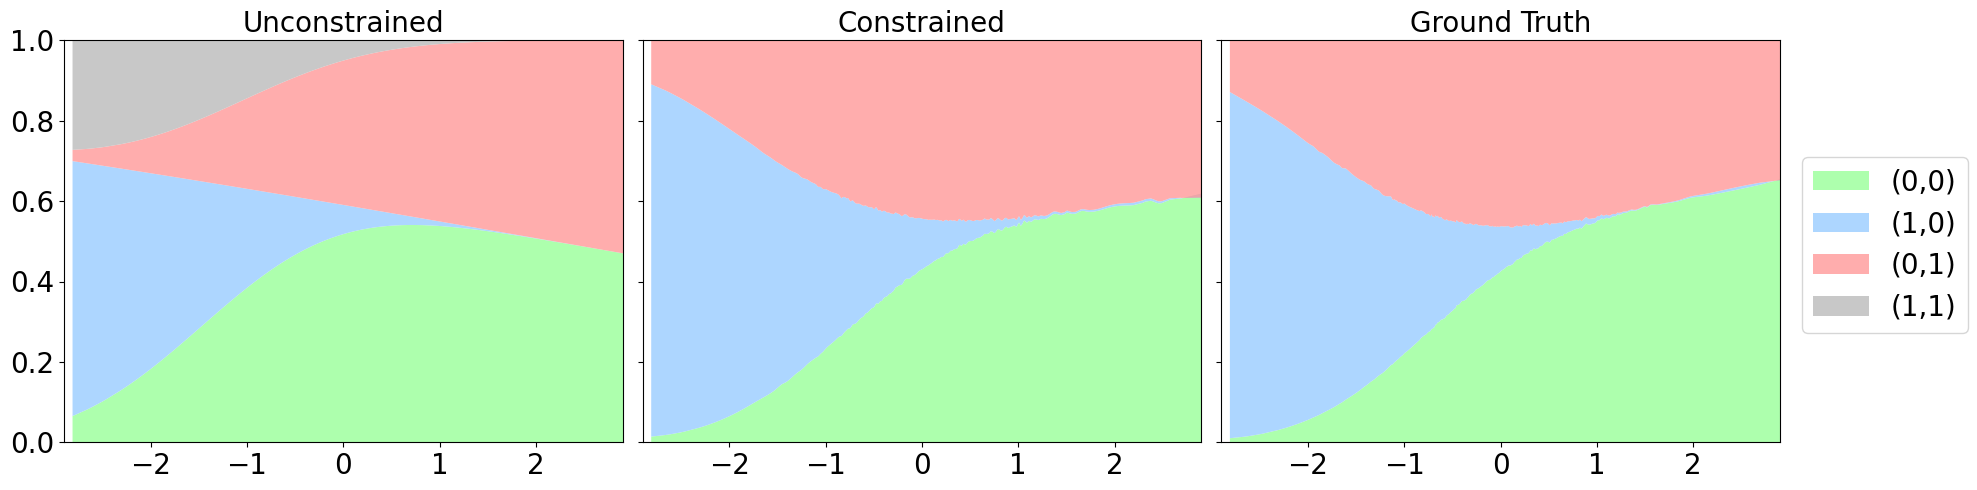

In [8]:
# Get the smooth version for better visualization
df_pred_aug_s = smooth_df_probs(df_pred_aug, smoothness=0.02)
df_pred_true_s = smooth_df_probs(df_pred_true, smoothness=0.02)


# Melt wide dataframes to long format
df_pred_long = df_pred.melt(id_vars="x", var_name="Y", value_name="prob")
df_pred_aug_long = df_pred_aug_s.melt(id_vars="x", var_name="Y", value_name="prob")
df_pred_true_long = df_pred_true_s.melt(id_vars="x", var_name="Y", value_name="prob")

# Add Method labels
df_pred_long["Method"] = "Unconstrained"
df_pred_aug_long["Method"] = "Constrained"
df_pred_true_long["Method"] = "Ground Truth"

# Combine into one long-form dataframe
df_all = pd.concat([df_pred_long, df_pred_aug_long, df_pred_true_long], ignore_index=True)

# Function to pivot and prepare data for stacking
def prepare_stacked(df_method):
    df_sorted = df_method.sort_values("x")
    df_pivot = df_sorted.pivot(index="x", columns="Y", values="prob").fillna(0)
    # Ensure column order
    df_pivot = df_pivot[["(0,0)", "(1,0)", "(0,1)", "(1,1)"]]
    return df_pivot

# Setup plotting
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
methods = ["Unconstrained", "Constrained", "Ground Truth"]
long_dfs = [df_pred_long, df_pred_aug_long, df_pred_true_long]
colors = ["#99ff99", "#99ccff", "#ff9999", "#bbbbbb"]

for ax, method, df_method in zip(axes, methods, long_dfs):
    df_method = df_method[df_method["Method"] == method]
    df_stacked = prepare_stacked(df_method)
    x_vals = df_stacked.index.values
    y_vals = df_stacked.values.T  # shape: (4, n_points)
    
    ax.stackplot(x_vals, y_vals, labels=df_stacked.columns, colors=colors, alpha=0.8)
    ax.set_title(method, fontsize=20)
    # ax.set_xlabel("X[:, 1]")
    ax.set_xlim([-2.9, 2.9])
    ax.set_ylim([0, 1])
    ax.tick_params(axis='x', labelsize=20)
    ax.tick_params(axis='y', labelsize=20)
    ax.grid(False)

# axes[0].set_ylabel("Predicted Probability")

# Shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="center", ncol=1, bbox_to_anchor=(1.05, 0.5), fontsize=20)

plt.tight_layout()
plt.show()


# Signal recovery and computational efficiency under various dimensions

We use ```batch_save_trace_plots``` and ```batch_save_ACF_plots``` to generate trace plots and ACF plots, respectively, for which we need to define the following arguments: 
- sample_dir: the directory under which the samples and the ground truth are stroed
- image_dir: the directory under which the generated plots are saved
- sample_files: a list of file names of beta samples
- truth_files: a list of file names of the true value of beta
- plot_specs: (Only for ```batch_save_trace_plot```) a list of dictionaries; the key ````param_indices``` of each dictionary contains the index of beta that you wish to plot the trace plots
- burn_in: the first ```burn_in``` values of the beta samples are discarded when plotting both the trace and ACF plots
- thin: only every ```thin```-th sample of the beta samples are retained when plotting the ACF plots

The following cells give an example to define the above and . It assumes that the samples and ground truths are stored under jasa-repo/results/runs/mh_within_gibbs/full_example

The generated plots are saved to jasa-repo/results/figures/mh_within_gibbs/trace_plots and jasa-repo/results/figures/mh_within_gibbs/acf_plots

In [25]:
# define sampel_dir and get sample_files and truth_files
sample_dir = "../../results/runs/mh_within_gibbs/full_example"

sample_files = []

for n_iter in [5000]:
    for n in [1000]:
        for rep in [1]:
            for d in [2, 5, 10]:
                for m in [1, 2, 5]:
                            file_name = f"rep{rep}_iter{n_iter}_n{n}_d{d}_p5_m{m}__kernelexponential__beta_samples.rds"
                            # if file exists, add to list
                            file_path = os.path.join(sample_dir, file_name)
                            if os.path.exists(file_path):
                                sample_files.append(file_name)

print(f"Found {len(sample_files)} sample files for Gibbs sampling.")
for _ in range(min(20, len(sample_files))):
    print(f"  {_}: {sample_files[_]}")


truth_files = []
for n_iter in [5000]:
    for n in [1000]:
        for rep in [1]:
            for d in [2, 5, 10]:
                for m in [1, 2, 5]:
                            file_name = f"rep{rep}_iter{n_iter}_n{n}_d{d}_p5_m{m}__kernelexponential__beta_true.rds"
                            # if file exists, add to list
                            file_path = os.path.join(sample_dir, file_name)
                            if os.path.exists(file_path):
                                truth_files.append(file_name)

print(f"Found {len(truth_files)} truth files for Gibbs sampling.")
for _ in range(min(20, len(truth_files))):
    print(f"  {_}: {truth_files[_]}")


# indexes to plot
plot_specs = []

for i in range(5):
    for j in range(2):
        plot_specs.append(
            {
                "param_indices": [(i, j)],
                "filename_pattern": "gibbs_beta",
            }
        )



Found 6 sample files for Gibbs sampling.
  0: rep1_iter5000_n1000_d2_p5_m1__kernelexponential__beta_samples.rds
  1: rep1_iter5000_n1000_d5_p5_m1__kernelexponential__beta_samples.rds
  2: rep1_iter5000_n1000_d5_p5_m2__kernelexponential__beta_samples.rds
  3: rep1_iter5000_n1000_d10_p5_m1__kernelexponential__beta_samples.rds
  4: rep1_iter5000_n1000_d10_p5_m2__kernelexponential__beta_samples.rds
  5: rep1_iter5000_n1000_d10_p5_m5__kernelexponential__beta_samples.rds
Found 6 truth files for Gibbs sampling.
  0: rep1_iter5000_n1000_d2_p5_m1__kernelexponential__beta_true.rds
  1: rep1_iter5000_n1000_d5_p5_m1__kernelexponential__beta_true.rds
  2: rep1_iter5000_n1000_d5_p5_m2__kernelexponential__beta_true.rds
  3: rep1_iter5000_n1000_d10_p5_m1__kernelexponential__beta_true.rds
  4: rep1_iter5000_n1000_d10_p5_m2__kernelexponential__beta_true.rds
  5: rep1_iter5000_n1000_d10_p5_m5__kernelexponential__beta_true.rds


### Trace plot

[INFO] ../../results/runs/mh_within_gibbs/full_example/rep1_iter5000_n1000_d2_p5_m1__kernelexponential__beta_samples.rds: raw S=5000, post burn-in+thin S=150
Initialized MCMCAnalysis for beta:
- Total iterations: 150
- Burn-in: 0
- Post burn-in iterations: 150
- Dimension 1 (dim1): 5
- Dimension 2 (dim2): 2
Plot saved to ../../results/figures/mh_within_gibbs/trace_plots/rep1_iter5000_n1000_d2_p5_m1__kernelexponential__beta_samples_beta_0_0_trace_burnin2000_thin20.png
[SAVED] ../../results/figures/mh_within_gibbs/trace_plots/rep1_iter5000_n1000_d2_p5_m1__kernelexponential__beta_samples_beta_0_0_trace_burnin2000_thin20.png
Plot saved to ../../results/figures/mh_within_gibbs/trace_plots/rep1_iter5000_n1000_d2_p5_m1__kernelexponential__beta_samples_beta_0_1_trace_burnin2000_thin20.png
[SAVED] ../../results/figures/mh_within_gibbs/trace_plots/rep1_iter5000_n1000_d2_p5_m1__kernelexponential__beta_samples_beta_0_1_trace_burnin2000_thin20.png
Plot saved to ../../results/figures/mh_within_gibbs

/var/folders/jc/zg27kqss4x3bfsymwd5yxvy00000gn/T/ipykernel_85676/322767218.py:282: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(5, 5))


Plot saved to ../../results/figures/mh_within_gibbs/trace_plots/rep1_iter5000_n1000_d5_p5_m2__kernelexponential__beta_samples_beta_0_1_trace_burnin2000_thin20.png
[SAVED] ../../results/figures/mh_within_gibbs/trace_plots/rep1_iter5000_n1000_d5_p5_m2__kernelexponential__beta_samples_beta_0_1_trace_burnin2000_thin20.png
Plot saved to ../../results/figures/mh_within_gibbs/trace_plots/rep1_iter5000_n1000_d5_p5_m2__kernelexponential__beta_samples_beta_1_0_trace_burnin2000_thin20.png
[SAVED] ../../results/figures/mh_within_gibbs/trace_plots/rep1_iter5000_n1000_d5_p5_m2__kernelexponential__beta_samples_beta_1_0_trace_burnin2000_thin20.png
Plot saved to ../../results/figures/mh_within_gibbs/trace_plots/rep1_iter5000_n1000_d5_p5_m2__kernelexponential__beta_samples_beta_1_1_trace_burnin2000_thin20.png
[SAVED] ../../results/figures/mh_within_gibbs/trace_plots/rep1_iter5000_n1000_d5_p5_m2__kernelexponential__beta_samples_beta_1_1_trace_burnin2000_thin20.png
Plot saved to ../../results/figures/mh_w

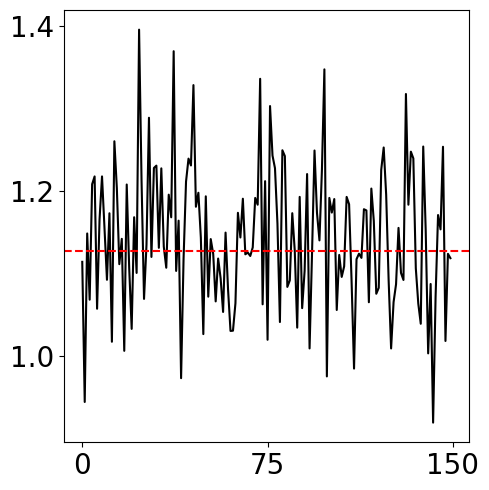

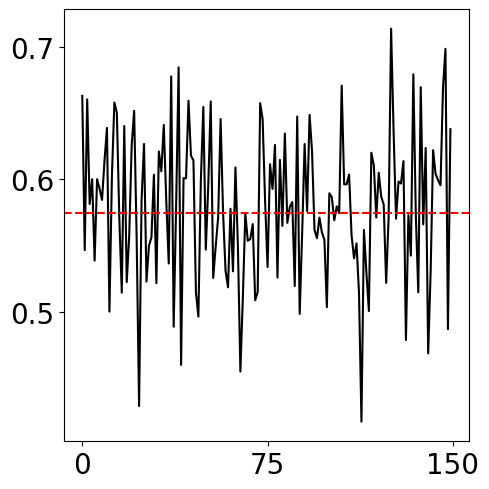

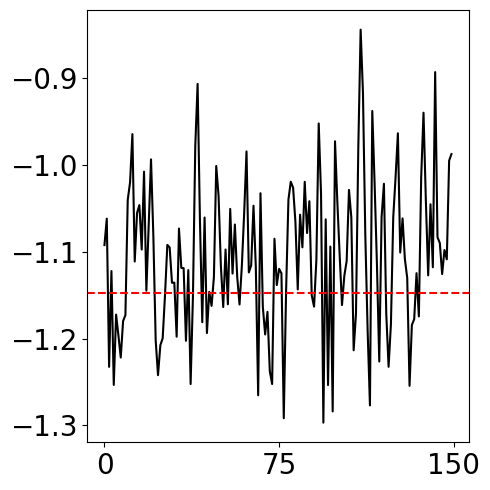

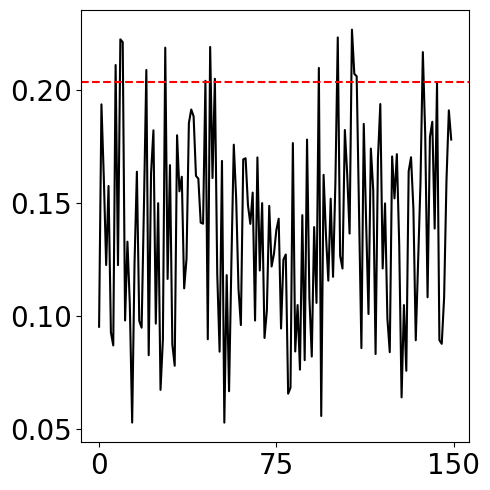

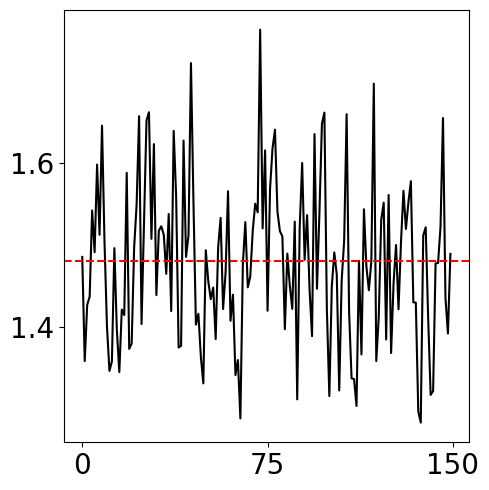

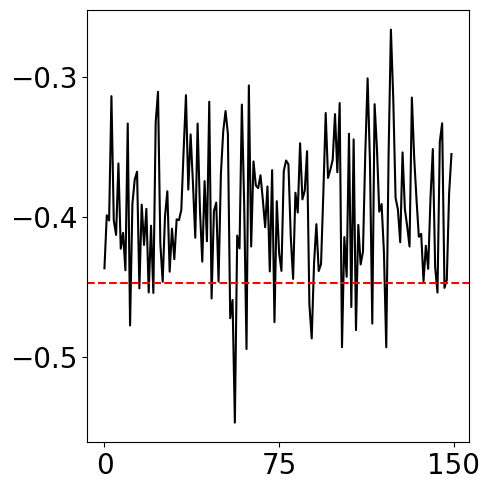

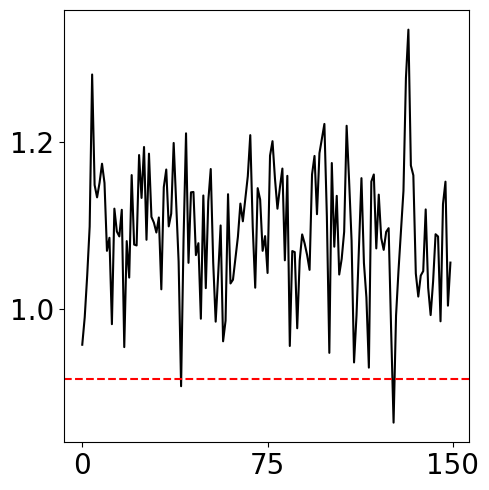

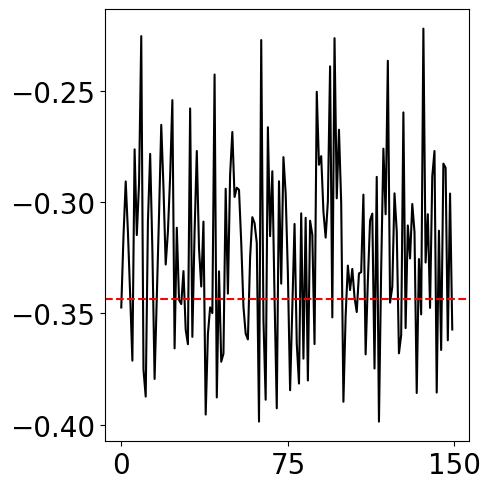

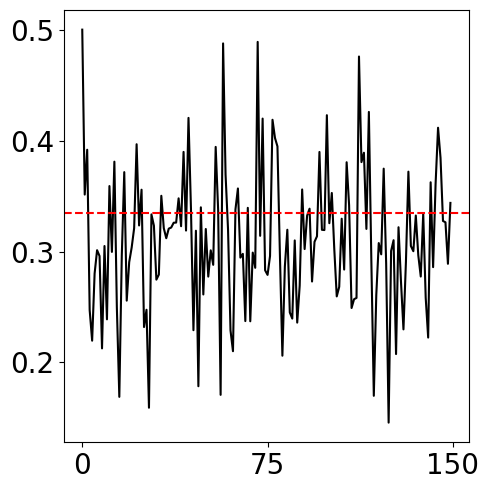

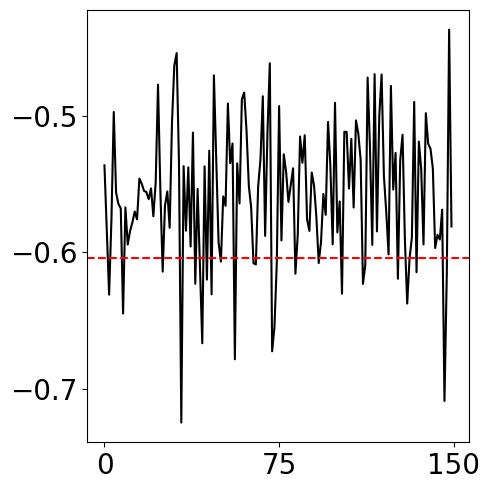

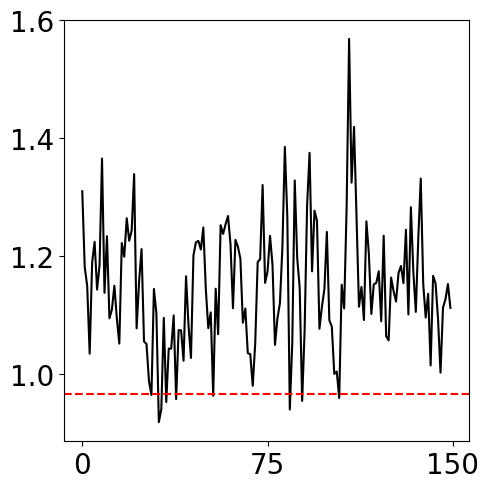

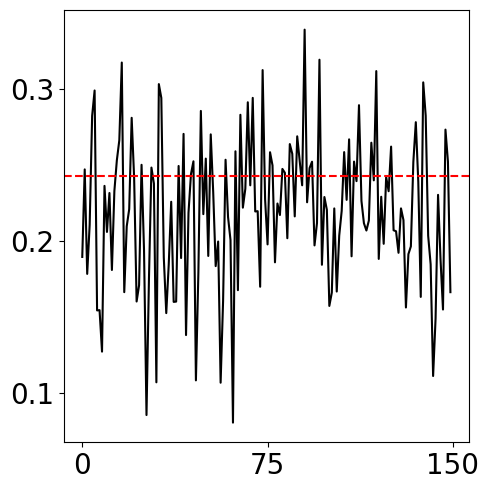

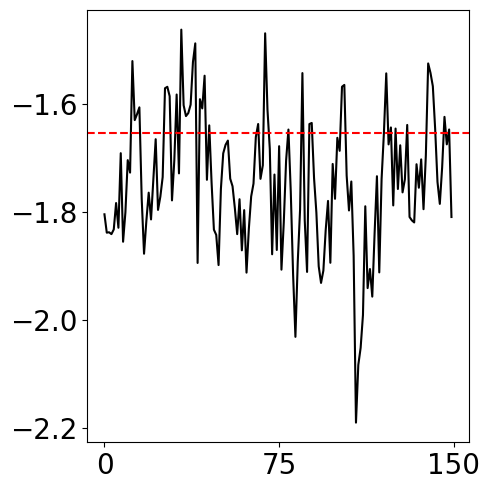

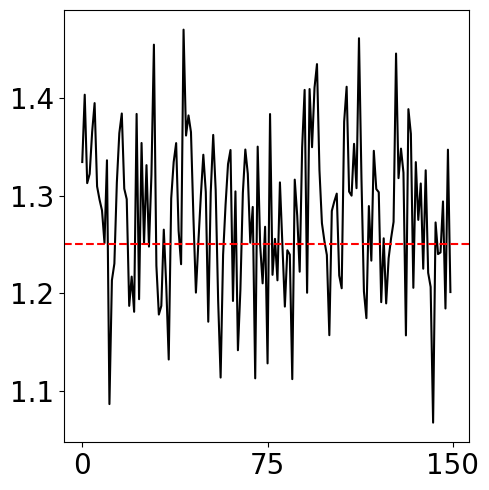

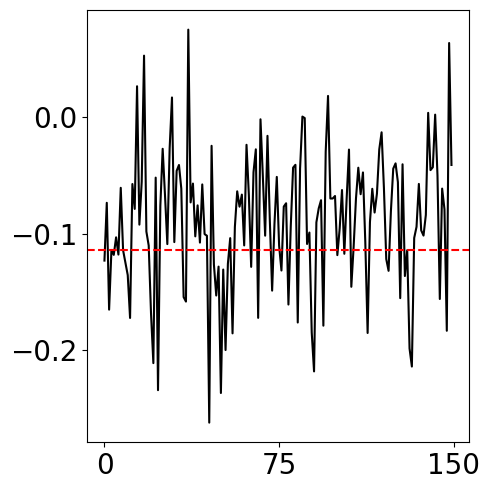

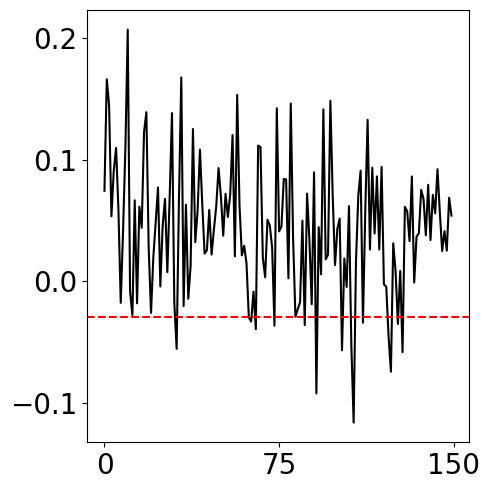

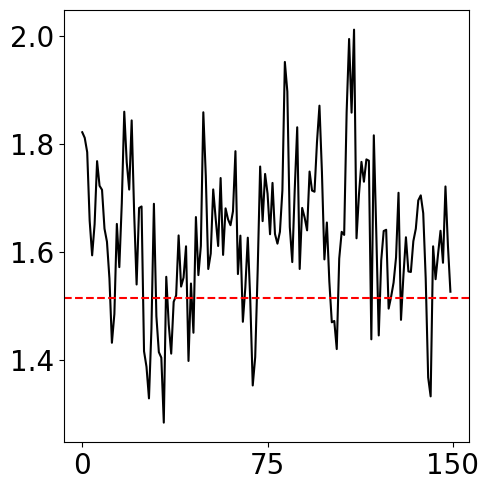

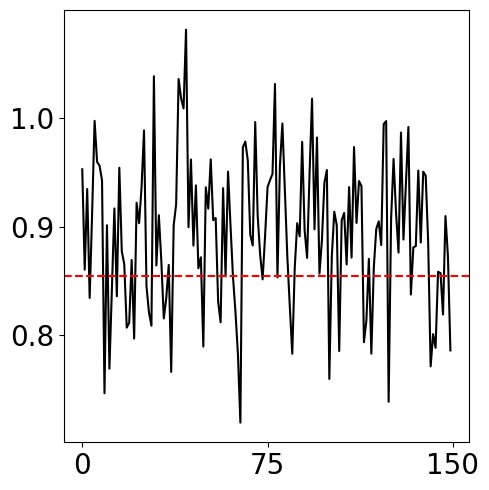

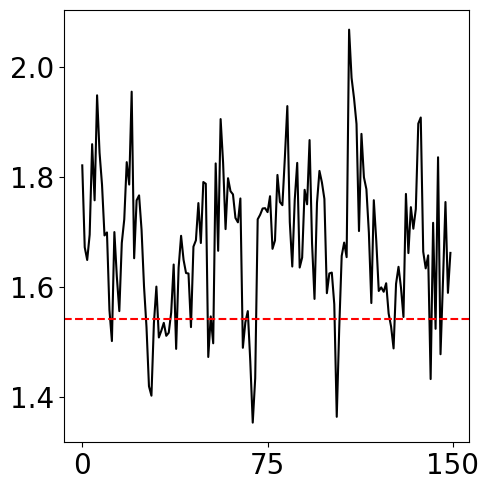

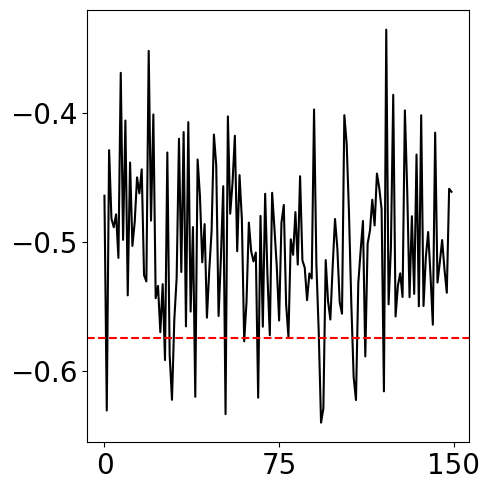

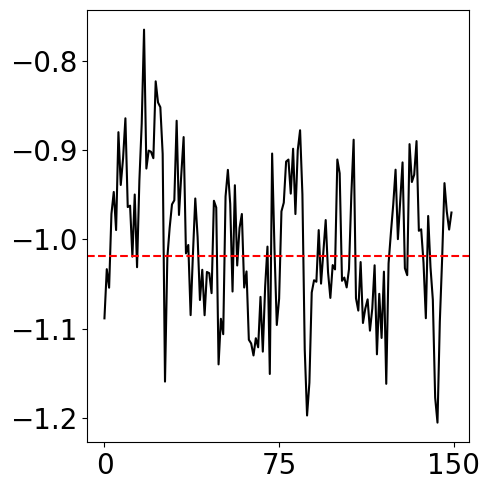

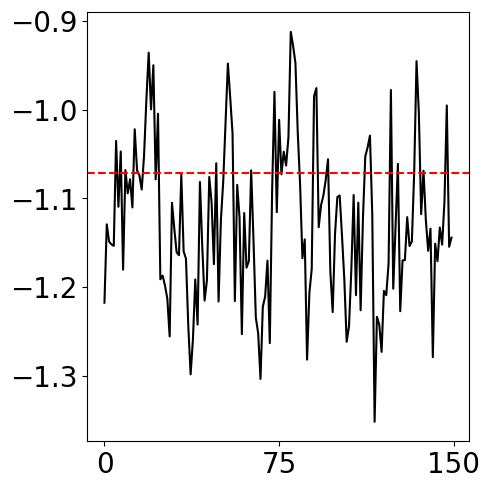

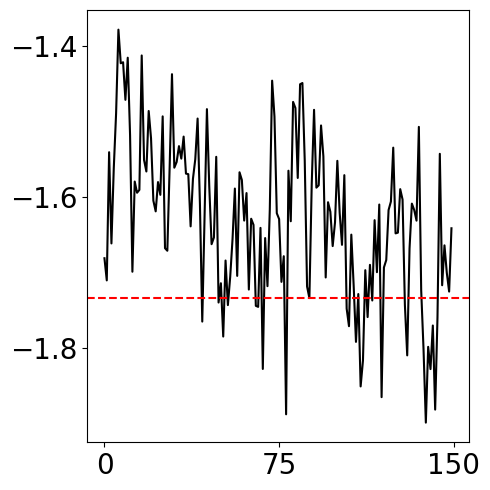

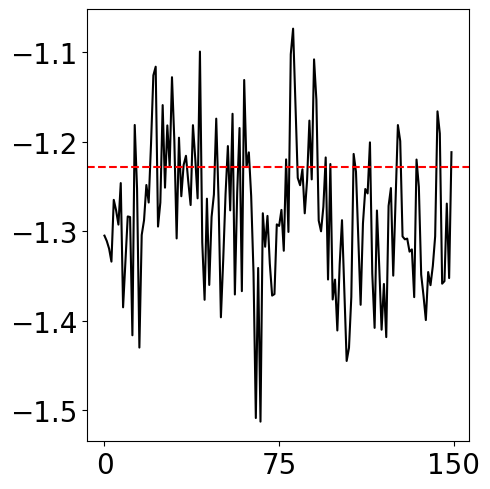

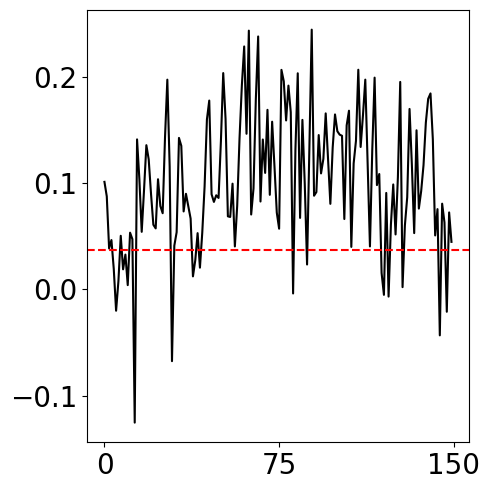

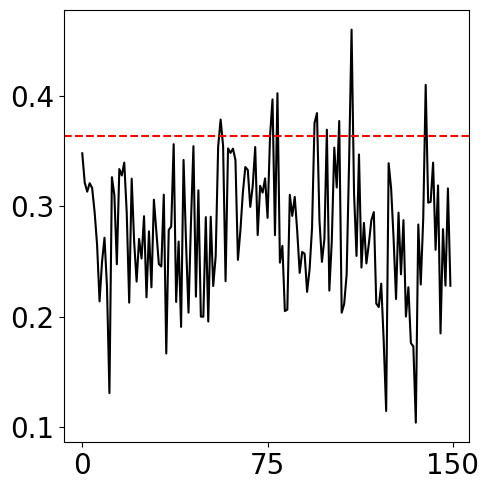

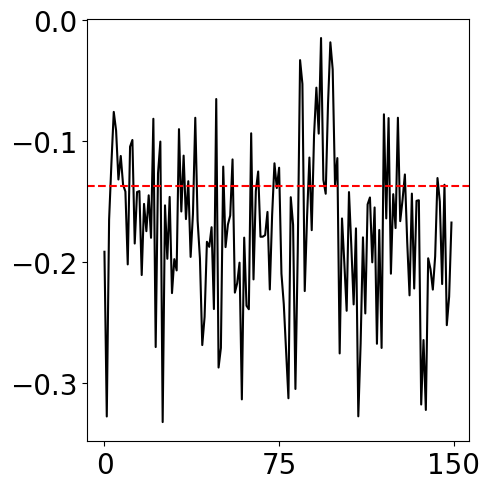

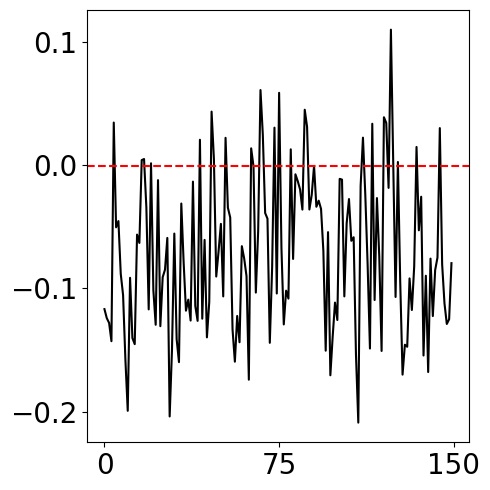

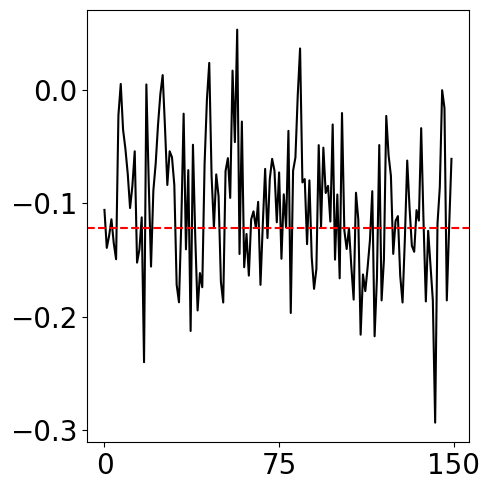

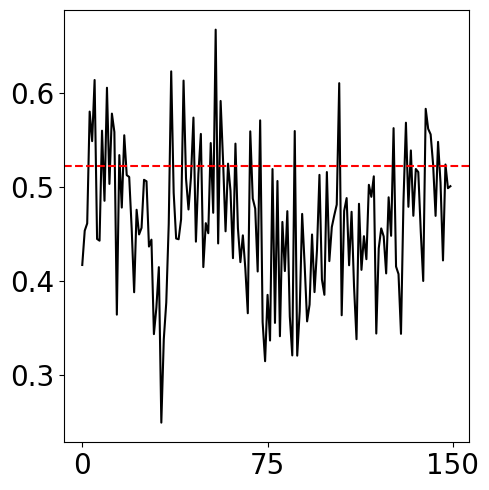

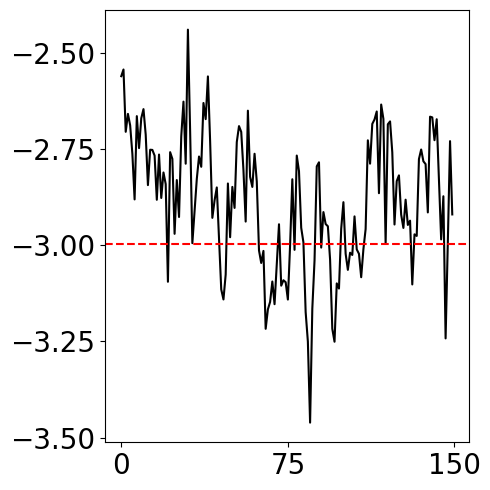

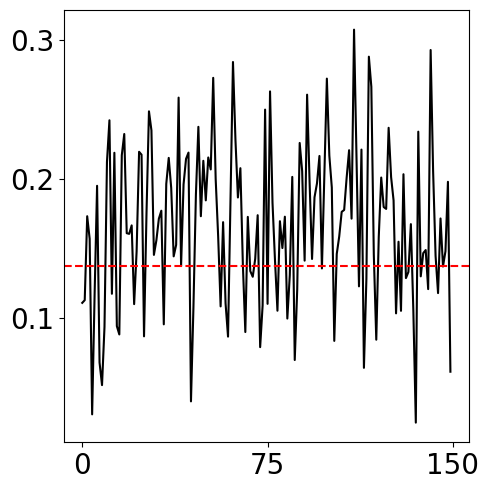

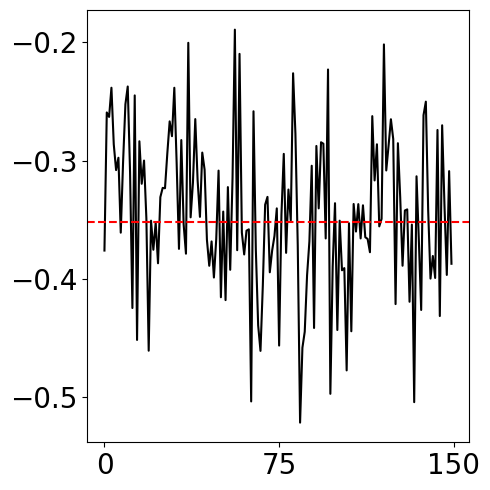

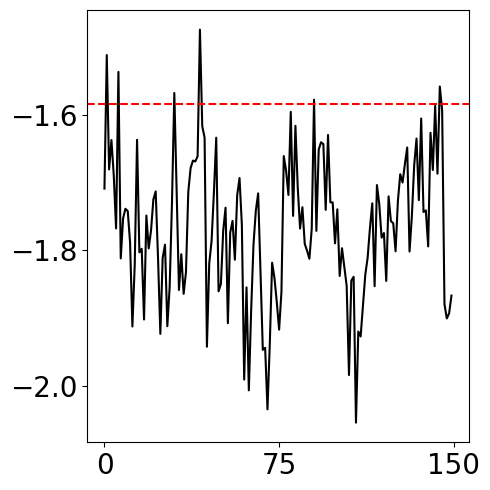

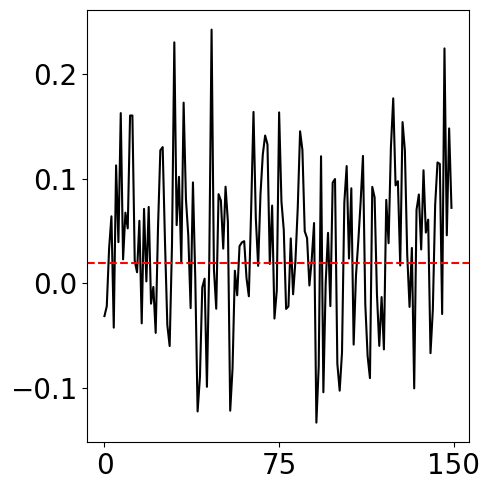

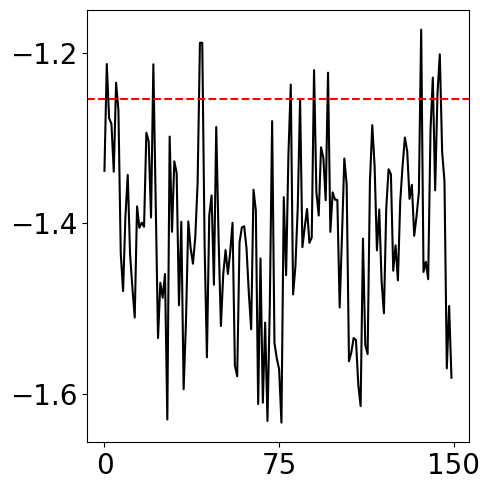

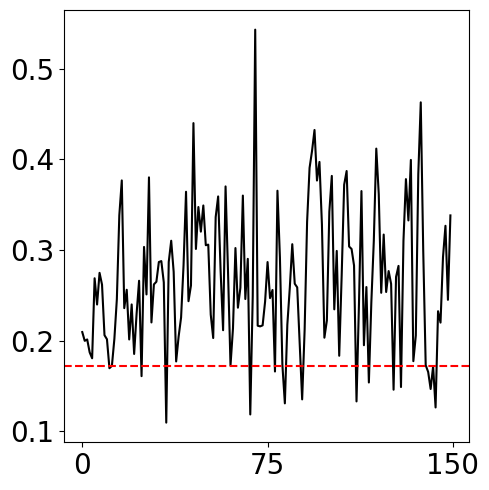

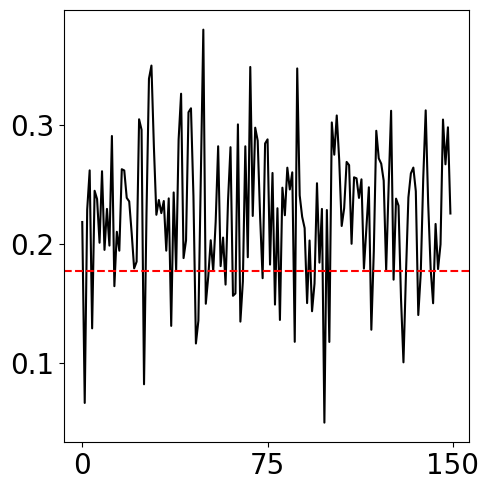

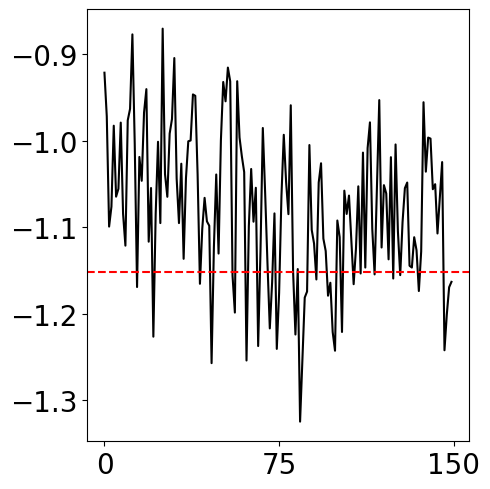

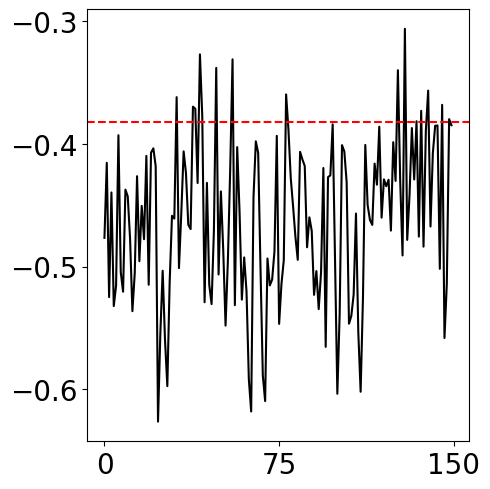

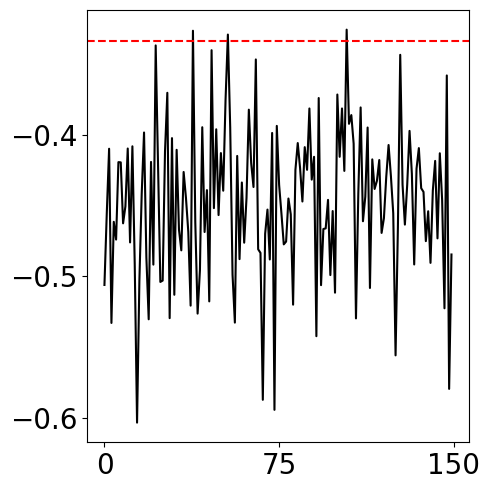

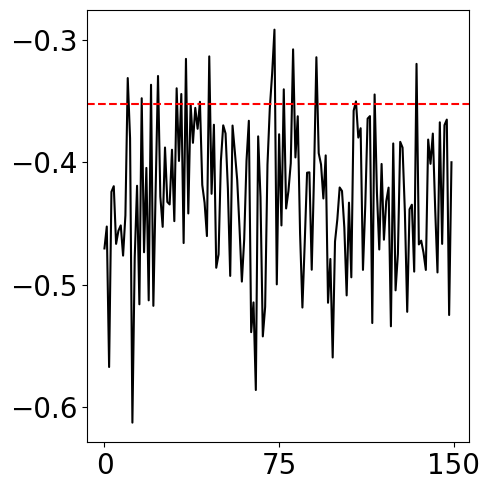

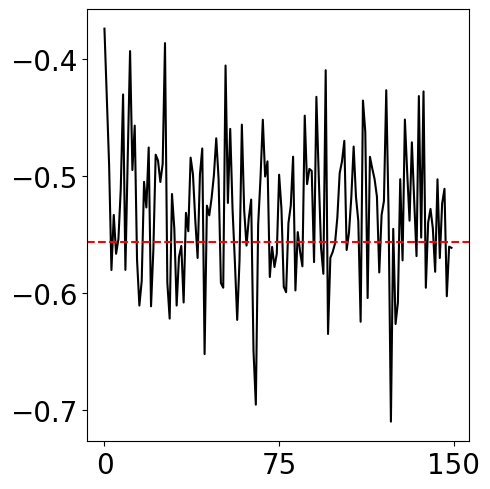

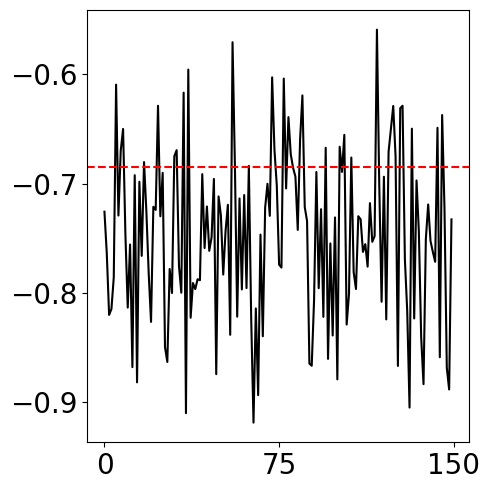

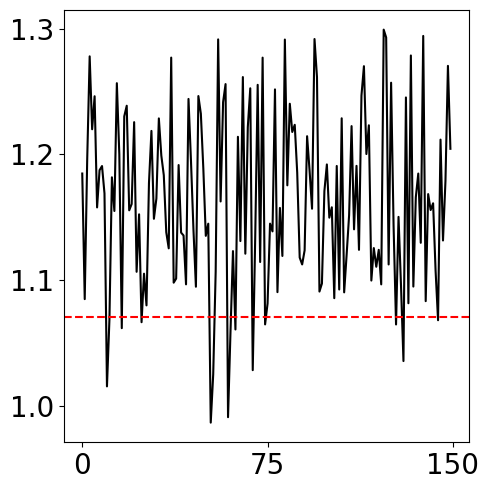

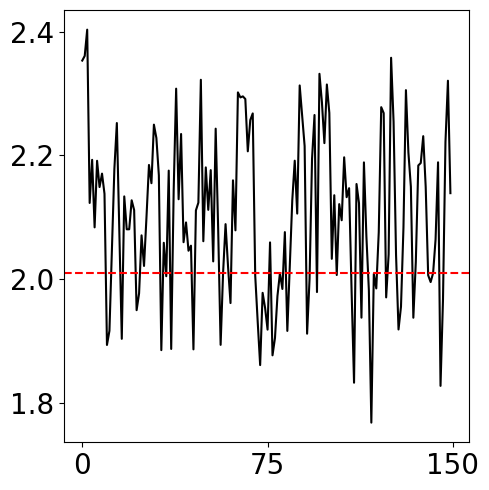

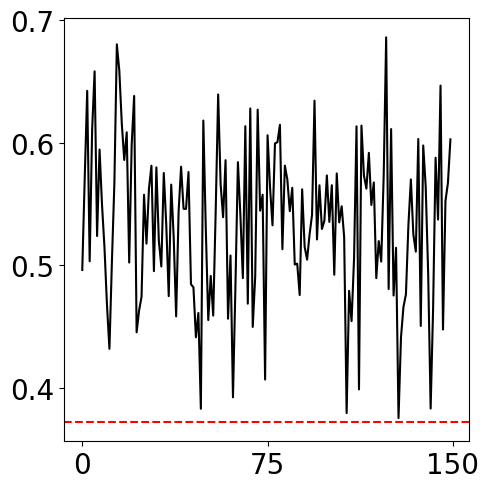

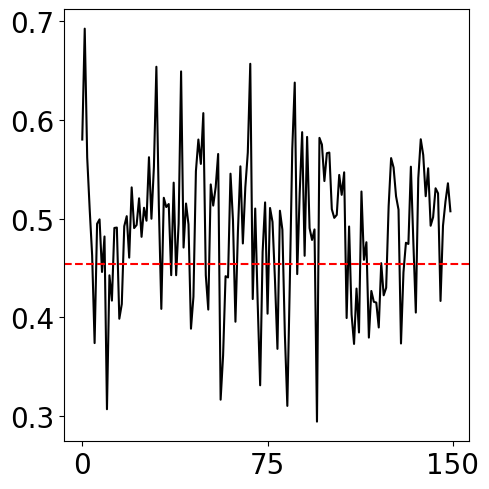

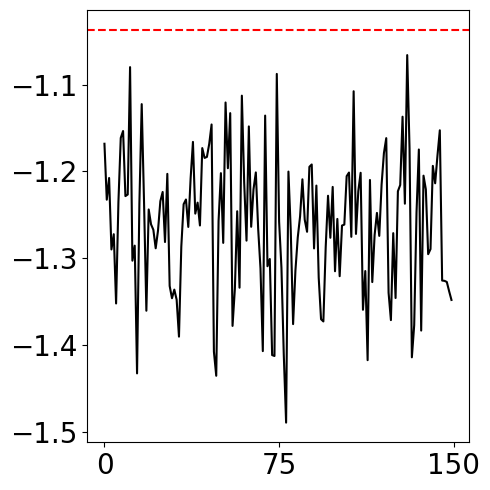

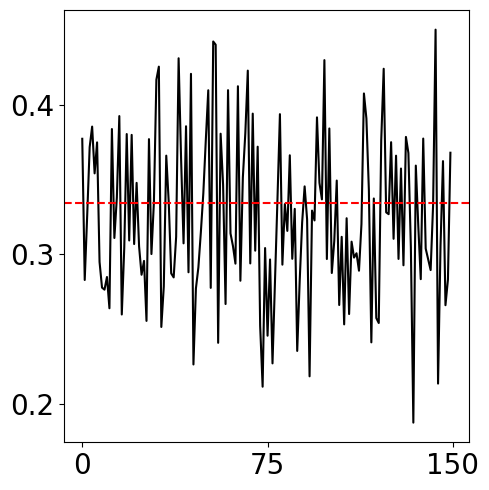

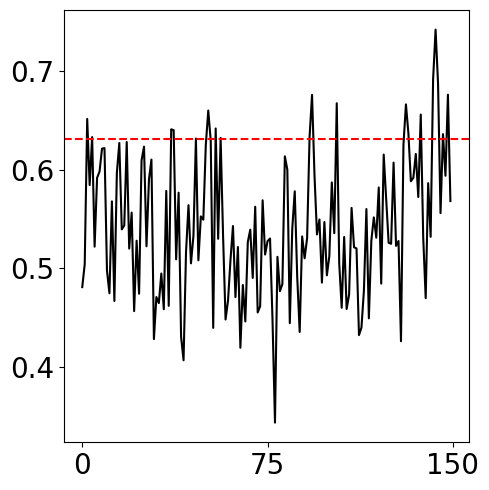

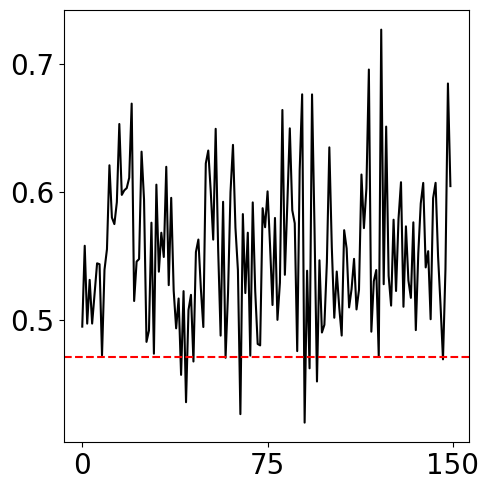

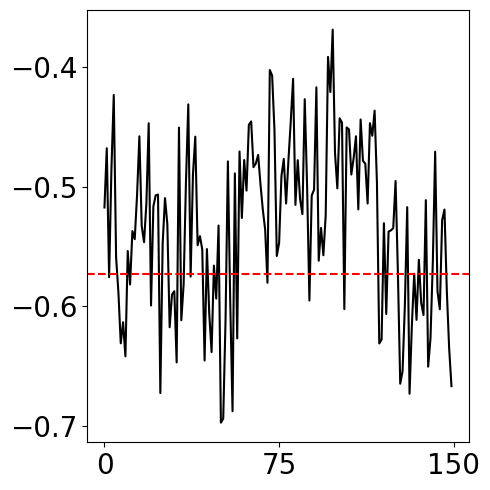

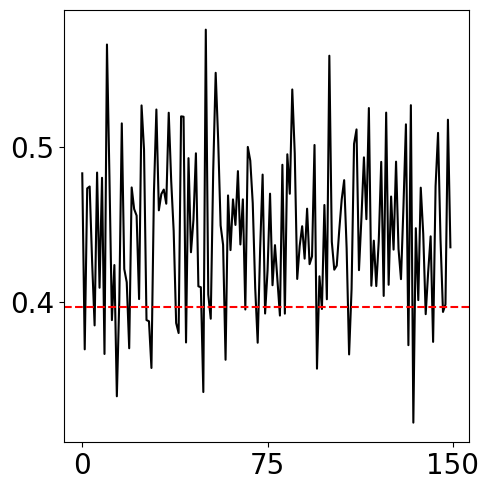

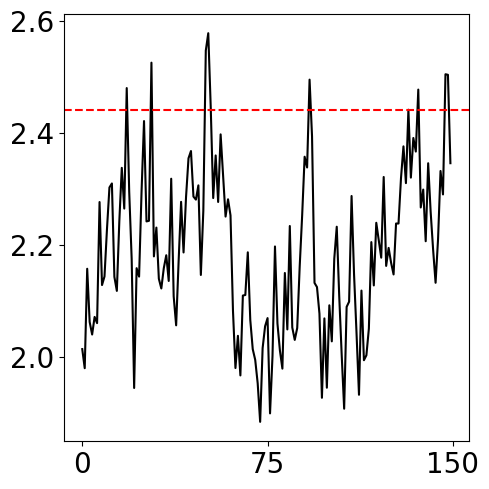

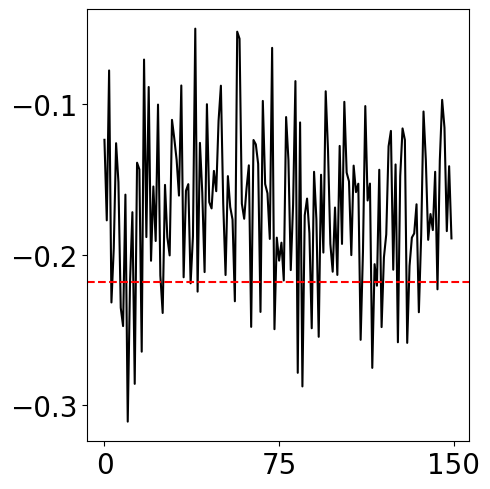

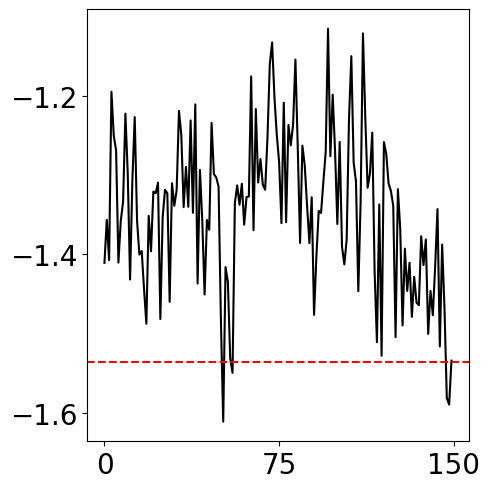

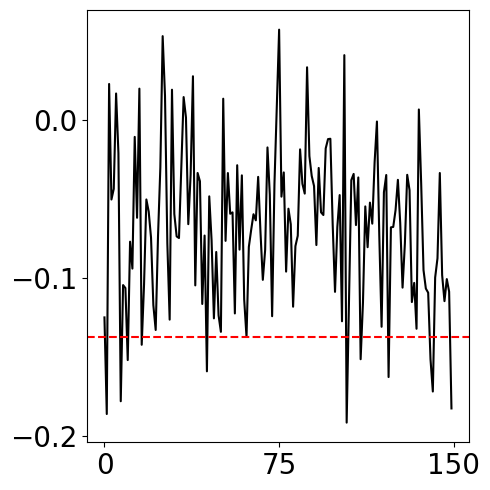

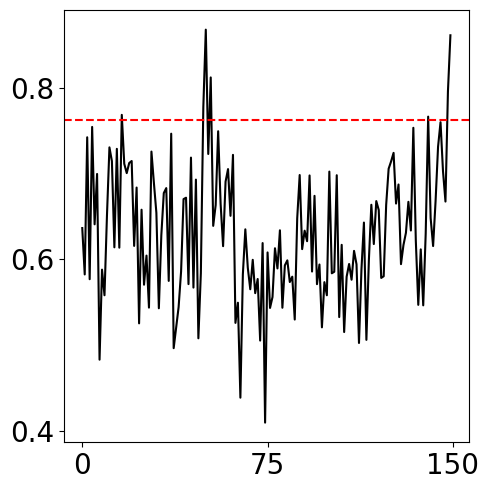

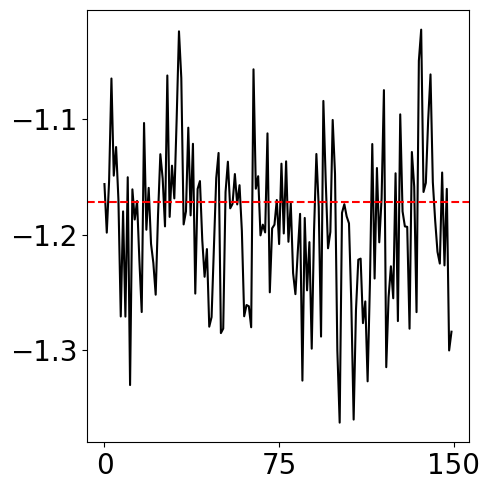

In [26]:
# Trace plots

image_dir  = "../../results/figures/mh_within_gibbs/trace_plots"
burn_in = 2000
thin = 20


batch_save_trace_plots(
    # Directories
    sample_dir=sample_dir,      # directory containing the samples and truth files
    image_dir=image_dir,        # directory to save the trace plot images
    # direct-file mode:
    sample_files=sample_files,
    truth_files=truth_files,          # provide truth files for Gibbs samples
    # common options:
    param_name="beta",
    burn_in=burn_in,      
    thin=thin,        
    plot_specs=plot_specs,
    clean_mode=True,
)

### ACF plot

In [ ]:
# ACF plots

image_dir  = "../../results/figures/mh_within_gibbs/acf_plots"
burn_in = 2000
thin = 20
max_lag = 35

batch_save_ACF_plots(
    sample_dir=sample_dir,
    image_dir=image_dir,
    sample_files=sample_files,   # direct-file mode
    param_name="beta",
    burn_in=burn_in,      
    thin=thin,
    max_lag=max_lag,
    clean_mode=True,
    tick_size=28,
)

### Violin plot

Initialized MCMCAnalysis for beta:
- Total iterations: 5000
- Burn-in: 2000
- Post burn-in iterations: 3000
- Dimension 1 (dim1): 5
- Dimension 2 (dim2): 10


/var/folders/jc/zg27kqss4x3bfsymwd5yxvy00000gn/T/ipykernel_85676/322767218.py:498: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="Parameter Index", y="Value", data=df_long, inner="box", scale="width", fill=False, palette=['black'])
/var/folders/jc/zg27kqss4x3bfsymwd5yxvy00000gn/T/ipykernel_85676/322767218.py:498: UserWarning: 
The palette list has fewer values (1) than needed (50) and will cycle, which may produce an uninterpretable plot.
  sns.violinplot(x="Parameter Index", y="Value", data=df_long, inner="box", scale="width", fill=False, palette=['black'])
/var/folders/jc/zg27kqss4x3bfsymwd5yxvy00000gn/T/ipykernel_85676/322767218.py:498: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(x="Parameter Index", y="Value", data=df_lo

Plot saved to ../../results/figures/mh_within_gibbs/violin_plots/rep1_iter5000_n1000_d10_p5_m5_beta_violin.png


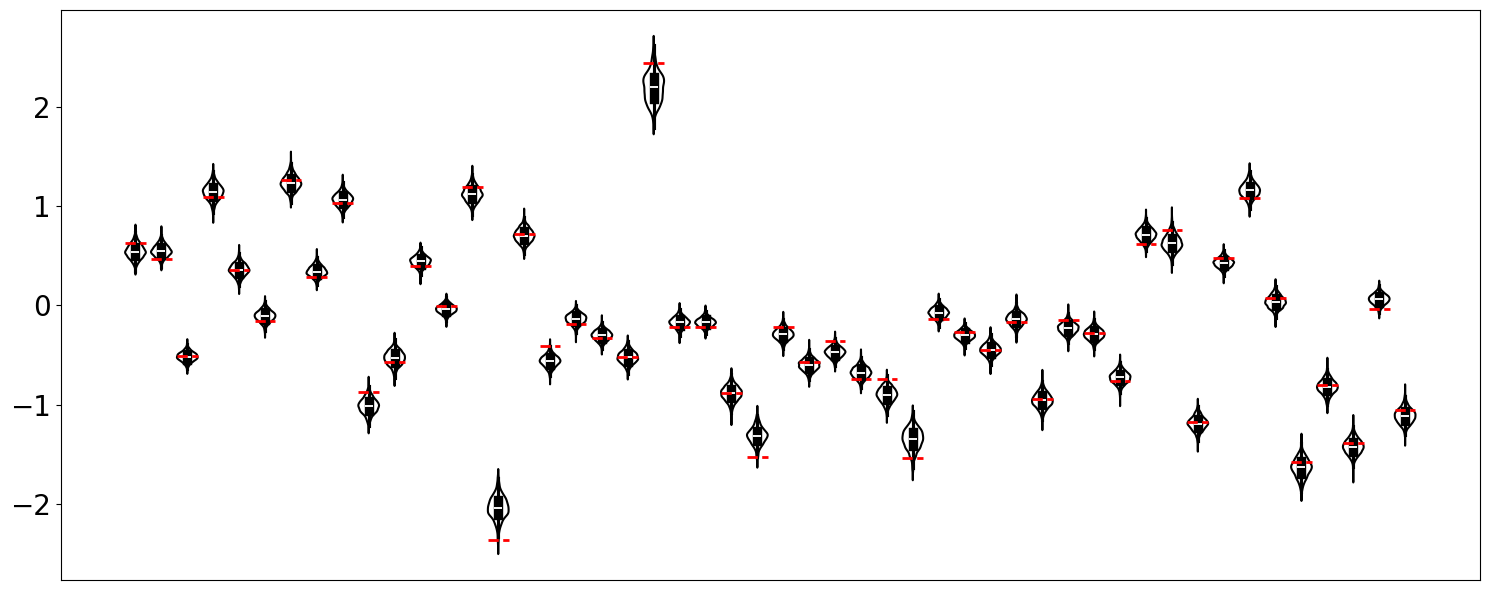

In [31]:
# violin plots

burn_in = 2000
rep = 1
n_iter = 5000
n, d, p, m = 1000, 10, 5, 5
beta_samples = _load_array_from_rds(os.path.join(sample_dir, f"rep{rep}_iter{n_iter}_n{n}_d{d}_p{p}_m{m}__kernelexponential__beta_samples.rds"))
beta_true = _load_array_from_rds(os.path.join(sample_dir, f"rep{rep}_iter{n_iter}_n{n}_d{d}_p{p}_m{m}__kernelexponential__beta_true.rds"))
image_dir  = "../../results/figures/mh_within_gibbs/violin_plots"

Analyzer_beta = MCMCAnalysis(beta_samples,
                             burn_in = burn_in,
                             param_name = "beta",
                             ground_truth = beta_true)


Analyzer_beta.plot_posterior_violin(config=3, clean_mode=True,
                                       save_path=os.path.join(image_dir, f"rep{rep}_iter{n_iter}_n{n}_d{d}_p{p}_m{m}_beta_violin.png"))

# Data analysis on waterfowl matching

In [45]:
DATA_DIR = "../../data/waterfowl_matching"
RESULT_DIR = "../../results/runs/data_analysis"
IMAGE_DIR = "../../results/figures/duck_matching"

In [ ]:
# Read the dataframe
ducks = np.load(os.path.join(DATA_DIR, "duck_data.pkl"), allow_pickle=True)
A = np.load(os.path.join(DATA_DIR, "A_tilde_matrix.npy"))
y = np.load(os.path.join(DATA_DIR, "Z_matrix.npy"))


In [42]:
# Read data application result (duck matching)
n_iterations, n, kappa, K = 50000, 18, 5, 7
d, m = 339, 95
burn_in = n_iterations // 2
rho_samples = np.array(pyreadr.read_r(os.path.join(RESULT_DIR, f"duck_iter{n_iterations}_n{n}_kappa{kappa}_K{K}_rho_samples.rds"))[None])
a_samples = np.array(pyreadr.read_r(os.path.join(RESULT_DIR, f"duck_iter{n_iterations}_n{n}_kappa{kappa}_K{K}_a_samples.rds"))[None])
B = np.loadtxt(os.path.join(RESULT_DIR, "B_matrix.csv"), delimiter=",", skiprows=1)

In [43]:
### MCMC Analysis
Analyzer = {}  # Dictionary to store MCMCAnalysis objects
Parameter_names = ['rho', 'a', 'a_aug']
Parameter_samples = {
    'rho': rho_samples[2000::20],
    'a': a_samples[2000::20,1:,None],
    'a_aug': a_samples[2000::20,:,None],
}

# Create MCMCAnalysis objects for each parameter
for name in Parameter_names:
    samples = Parameter_samples[name]
    Analyzer[name] = MCMCAnalysis(samples, burn_in=0, param_name=name, ground_truth=None)

Initialized MCMCAnalysis for rho:
- Total iterations: 2400
- Burn-in: 0
- Post burn-in iterations: 2400
- Dimension 1 (dim1): 5
- Dimension 2 (dim2): 7
Initialized MCMCAnalysis for a:
- Total iterations: 2400
- Burn-in: 0
- Post burn-in iterations: 2400
- Dimension 1 (dim1): 2
- Dimension 2 (dim2): 1
Initialized MCMCAnalysis for a_aug:
- Total iterations: 2400
- Burn-in: 0
- Post burn-in iterations: 2400
- Dimension 1 (dim1): 3
- Dimension 2 (dim2): 1


In [ ]:
# Save trace plots and acf plots of rho
param_indices = [(i,j) for i in range(rho_samples.shape[1]) for j in range(rho_samples.shape[2])]

for ind in param_indices:
    Analyzer['rho'].trace_plots(config=2, clean_mode=True, param_indices=[ind],
                                save_path=os.path.join(IMAGE_DIR, f"duck_iter{n_iterations}_n{n}_kappa{kappa}_K{K}_rho_{ind[0]}_{ind[1]}_thinned_trace.png"))
    
Analyzer['rho'].plot_ACF(max_lag=35, thinning=1, config=2, clean_mode=True, tick_size=28,
                         save_path=os.path.join(IMAGE_DIR, f"duck_iter{n_iterations}_n{n}_kappa{kappa}_K{K}_rho_acf.png"))


In [ ]:
# Save trace plots and acf plots of a
param_indices = [(i,0) for i in range(a_samples.shape[1])]

for ind in param_indices:
    Analyzer['a_aug'].trace_plots(config=2, clean_mode=True, param_indices=[ind],
                                save_path=os.path.join(IMAGE_DIR, f"duck_iter{n_iterations}_n{n}_kappa{kappa}_K{K}_a_{ind[0]}_{ind[1]}_thinned_trace.png"))
    
Analyzer['a_aug'].plot_ACF(max_lag=35, thinning=1, config=2, clean_mode=True, tick_size=28,
                           save_path=os.path.join(IMAGE_DIR, f"duck_iter{n_iterations}_n{n}_kappa{kappa}_K{K}_a_acf.png"))


In [50]:
# Get 95% CI of a
# Assume a_samples is a NumPy array of shape (n_iterations, 3)
posterior_samples = a_samples[2000::20]

# Posterior mean for each parameter
posterior_mean = posterior_samples.mean(axis=0)

# 95% credible intervals (2.5% and 97.5% quantiles)
credible_intervals = np.percentile(posterior_samples, [2.5, 97.5], axis=0)

# Display results
for i in range(posterior_samples.shape[1]):
    print(f"Parameter {i+1}:")
    print(f"  Mean = {posterior_mean[i]:.4f}")
    print(f"  95% CI = ({credible_intervals[0, i]:.4f}, {credible_intervals[1, i]:.4f})\n")


Parameter 1:
  Mean = -1.7977
  95% CI = (-2.6349, -0.9729)

Parameter 2:
  Mean = 0.0118
  95% CI = (-0.0976, 0.1239)

Parameter 3:
  Mean = 0.1877
  95% CI = (0.0101, 0.3704)



In [51]:
# Get the indexes of ducks of medium weight for male and female, respectively
median_indices = {}

# Group by species
for species, group in ducks.groupby('duck_species'):
    median_male = group['duck_weight_male'].median()
    median_female = group['duck_weight_female'].median()
    
    # Compute squared distance to median for each row
    distances = (group['duck_weight_male'] - median_male) ** 2 + (group['duck_weight_female'] - median_female) ** 2
    
    # Find index of row with smallest distance
    min_index = distances.idxmin()
    median_indices[species] = min_index

print(median_indices)


{'American Black Duck': 71, 'Canvasback': 297, 'Gadwall': 161, 'Mallard': 102, 'Redhead': 250, 'Ring-necked Duck': 321, 'Scaup': 233}


In [52]:
# Construct C
def construct_C_from_ducks(species_vec):
    species_vec = pd.Series(species_vec)  # Ensure it's a Series for indexing
    species_levels = species_vec.drop_duplicates().tolist()  # preserve order
    K = len(species_levels)
    d = len(species_vec)
    
    C = np.zeros((K, d), dtype=int)
    
    # Fill the matrix
    for j in range(d):
        k = species_levels.index(species_vec.iloc[j])
        C[k, j] = 1
    
    s_list = C.sum(axis=1)
    
    return {"C": C, "s_list": s_list, "species_levels": species_levels}

# Example usage
result = construct_C_from_ducks(ducks['duck_species'])
C = result["C"]
s_list = result["s_list"]

# Generate W_1, W_2, W_3
W1 = np.ones((n, d))
W2 = np.tile(ducks['duck_weight_male'].values, (n, 1))
W3 = np.tile(ducks['duck_weight_female'].values, (n, 1))


In [ ]:
# Get constraint matrix A which looses the constraint on male ducks,
# i.e., male ducks can match with multiple female ducks

female_ducks = ducks[['duck_species', 'duck_weight_female']].drop_duplicates()

female_duck_to_row = {
    (row['duck_species'], row['duck_weight_female']): i
    for i, (idx, row) in enumerate(female_ducks.iterrows())
}

A_female_only = np.zeros((len(female_duck_to_row), d))

for j in range(d):
    duck_id = (ducks['duck_species'][j], ducks['duck_weight_female'][j])
    row_ind = female_duck_to_row[duck_id]
    A_female_only[row_ind, j] = 1


# Get constraint matrix A which looses the constraint on female ducks,
# i.e., female ducks can match with multiple female ducks

male_ducks = ducks[['duck_species', 'duck_weight_male']].drop_duplicates()

male_duck_to_row = {
    (row['duck_species'], row['duck_weight_male']): i
    for i, (idx, row) in enumerate(male_ducks.iterrows())
}

A_male_only = np.zeros((len(male_duck_to_row), d))

for j in range(d):
    duck_id = (ducks['duck_species'][j], ducks['duck_weight_male'][j])
    row_ind = male_duck_to_row[duck_id]
    A_male_only[row_ind, j] = 1


    


In [55]:
# Count the number of male and female ducks in each species

print(
    male_ducks.groupby('duck_species').size(),
    "\n",
    female_ducks.groupby('duck_species').size()
)

duck_species
American Black Duck    10
Canvasback              5
Gadwall                 7
Mallard                 7
Redhead                 6
Ring-necked Duck        5
Scaup                   6
dtype: int64 
 duck_species
American Black Duck    10
Canvasback              5
Gadwall                 7
Mallard                 8
Redhead                 7
Ring-necked Duck        5
Scaup                   7
dtype: int64


In [56]:
def gen_prob_dict(sim_y, Gender='male', Competition=False, ducks=ducks, median_indices=median_indices):
    """
    Given the simulation results, the duck data, and the median indices,
    generate a dictionary of probabilities for matching over time
    """
    if Gender == 'male' and Competition == False:
        prob_match_male_dict = {}

        for species, ind in median_indices.items():
            median_male_weight = ducks['duck_weight_male'][ind]
            
            # Get edges with median-weight male and target species
            is_target_median_male = (
                (ducks['duck_weight_male'] == median_male_weight) &
                (ducks['duck_species'] == species)
            )
            
            matched_edges_for_median_male = sim_y[:, :, is_target_median_male]  # (n_sim, n_weeks, e1)
            matched_any = np.any(matched_edges_for_median_male, axis=2)         # (n_sim, n_weeks)
            
            # All edges with females of the target species
            is_female_of_species = ducks['duck_species'] == species
            ducks_species_subset = ducks[is_female_of_species]
            
            # Get unique female weights in this species
            unique_female_weights = ducks_species_subset['duck_weight_female'].unique()
            
            # For each female weight, determine if matched in each sim/week
            n_sim, n_weeks = sim_y.shape[:2]
            matched_by_female = np.zeros((n_sim, n_weeks, len(unique_female_weights)), dtype=bool)

            for i, weight in enumerate(unique_female_weights):
                # Edges involving this specific female duck (by weight)
                is_this_female = (
                    (ducks['duck_species'] == species) &
                    (ducks['duck_weight_female'] == weight)
                )
                matched_edges = sim_y[:, :, is_this_female]  # (n_sim, n_weeks, e2)
                matched_by_female[:, :, i] = np.any(matched_edges, axis=2)  # (n_sim, n_weeks)
            
            # For each sim/week: are ALL females matched by other male ducks?
            all_females_taken = np.all(matched_by_female, axis=2)  # (n_sim, n_weeks)
            all_females_taken_by_other_ducks = all_females_taken & ~matched_any  # (n_sim, n_weeks)
            valid_mask = ~all_females_taken_by_other_ducks                        # (n_sim, n_weeks)

            # Count valid and successful matches
            n_matched = np.sum(matched_any & valid_mask, axis=0)  # (n_weeks,)
            n_valid = np.sum(valid_mask, axis=0)                  # (n_weeks,)
            
            prob = n_matched / n_valid

            prob_match_male_dict[species] = prob
            
        return prob_match_male_dict
        
    if Gender == 'male' and Competition == True:
        prob_male_uncorrected_dict = {}

        for species, ind in median_indices.items():
            median_male_weight = ducks['duck_weight_male'][ind]
            
            # Boolean mask: all edges where the male has median weight and same species
            is_median_male = (
                (ducks['duck_species'] == species) &
                (ducks['duck_weight_male'] == median_male_weight)
            )

            # Extract sim_y across those edges: shape (n_sim, n_weeks, n_edges_with_median_male)
            y_subset = sim_y[:, :, is_median_male]

            # For each sim & week: did the median male match anyone?
            matched_any = np.any(y_subset, axis=2)  # shape: (n_sim, n_weeks), bool

            # Average over simulations to get match probability per week
            prob_match_median_male_duck = matched_any.mean(axis=0)  # shape: (n_weeks,)

            prob_male_uncorrected_dict[species] = prob_match_median_male_duck
        
        return prob_male_uncorrected_dict

    
    if Gender == 'female' and Competition == False:
        prob_match_female_dict = {}

        for species, ind in median_indices.items():
            median_female_weight = ducks['duck_weight_female'][ind]
            
            # Get edges with median-weight female and target species
            is_target_median_female = (
                (ducks['duck_weight_female'] == median_female_weight) &
                (ducks['duck_species'] == species)
            )
            
            matched_edges_for_median_female = sim_y[:, :, is_target_median_female]  # (n_sim, n_weeks, e1)
            matched_any = np.any(matched_edges_for_median_female, axis=2)           # (n_sim, n_weeks)
            
            # All edges with males of the target species
            is_male_of_species = ducks['duck_species'] == species
            ducks_species_subset = ducks[is_male_of_species]
            
            # Get unique male weights in this species
            unique_male_weights = ducks_species_subset['duck_weight_male'].unique()
            
            # For each male weight, determine if matched in each sim/week
            n_sim, n_weeks = sim_y.shape[:2]
            matched_by_male = np.zeros((n_sim, n_weeks, len(unique_male_weights)), dtype=bool)

            for i, weight in enumerate(unique_male_weights):
                is_this_male = (
                    (ducks['duck_species'] == species) &
                    (ducks['duck_weight_male'] == weight)
                )
                matched_edges = sim_y[:, :, is_this_male]
                matched_by_male[:, :, i] = np.any(matched_edges, axis=2)
            
            # Check whether all males were taken by other females
            all_males_taken = np.all(matched_by_male, axis=2)              # (n_sim, n_weeks)
            all_males_taken_by_other_ducks = all_males_taken & ~matched_any
            valid_mask = ~all_males_taken_by_other_ducks                   # (n_sim, n_weeks)

            # Count valid and successful matches
            n_matched = np.sum(matched_any & valid_mask, axis=0)
            n_valid = np.sum(valid_mask, axis=0)

            prob = n_matched / n_valid
            prob_match_female_dict[species] = prob

        return prob_match_female_dict

    if Gender == 'female' and Competition == True:
        prob_female_uncorrected_dict = {}

        for species, ind in median_indices.items():
            median_female_weight = ducks['duck_weight_female'][ind]
            
            # Boolean mask: all edges where the male has median weight and same species
            is_median_female = (
                (ducks['duck_species'] == species) &
                (ducks['duck_weight_female'] == median_female_weight)
            )

            # Extract sim_y across those edges: shape (n_sim, n_weeks, n_edges_with_median_male)
            y_subset = sim_y[:, :, is_median_female]

            # For each sim & week: did the median male match anyone?
            matched_any = np.any(y_subset, axis=2)  # shape: (n_sim, n_weeks), bool

            # Average over simulations to get match probability per week
            prob_match_median_female_duck = matched_any.mean(axis=0)  # shape: (n_weeks,)

            prob_female_uncorrected_dict[species] = prob_match_median_female_duck
        
        return prob_female_uncorrected_dict
        
        
    
        

        

In [64]:
# Get 95% Credible Band for Probability estimates using Monte Carlo Integration
n_weeks = 18
a_subsamples = a_samples[2000::20]
rho_subsamples = rho_samples[2000::20]
n_samples = len(a_subsamples)
n_sim = 1000 # number of Monte Carlo simulations

# Define save path
save_dir = os.path.join(RESULT_DIR, "ci_related_reduced")
os.makedirs(save_dir, exist_ok=True)  # Make directory if it doesn't exist


# Use defaultdict with a callable factory to avoid shared references
def zero_matrix():
    return np.zeros((n_samples, n_weeks))

all_prob_match_male_dict = defaultdict(zero_matrix)
all_prob_match_female_dict = defaultdict(zero_matrix)
all_prob_match_male_uncorrected_dict = defaultdict(zero_matrix)
all_prob_match_female_uncorrected_dict = defaultdict(zero_matrix)


for m, (a, rho) in tqdm(enumerate(zip(a_subsamples, rho_subsamples)), desc="Getting Credible Band"):
    mu = a[0] * W1 + a[1] * W2 + a[2] * W3 + B @ rho @ C

    sim_y = np.zeros((n_sim, n, d))
    for it in range(n_sim):
        zeta = mu + np.random.normal(size=(n, d))  # Simulate standard Gaussian
        for i in range(n):
            res = linprog(c=-zeta[i], A_ub=A, b_ub=np.ones(A.shape[0]), bounds=[(0, 1)] * d, method='highs')
            if res.success:
                sim_y[it, i] = np.round(res.x).astype(int)
            else:
                print(f"Optimization failed at iter {it}, row {i}. Skipping.")
                continue


    # Get corrected estimates
    prob_match_male_dict = gen_prob_dict(
        Gender='male', Competition=False, sim_y=sim_y, ducks=ducks, median_indices=median_indices
    )
    prob_match_female_dict = gen_prob_dict(
        Gender='female', Competition=False, sim_y=sim_y, ducks=ducks, median_indices=median_indices
    )

    for spec in prob_match_male_dict:
        all_prob_match_male_dict[spec][m] = prob_match_male_dict[spec]
    for spec in prob_match_female_dict:
        all_prob_match_female_dict[spec][m] = prob_match_female_dict[spec]



    # Get uncorrected estimates
    prob_match_male_uncorrected = gen_prob_dict(
        Gender='male', Competition=True, sim_y=sim_y, ducks=ducks, median_indices=median_indices
    )
    prob_match_female_uncorrected = gen_prob_dict(
        Gender='female', Competition=True, sim_y=sim_y, ducks=ducks, median_indices=median_indices
    )

    for spec in prob_match_male_uncorrected:
        all_prob_match_male_uncorrected_dict[spec][m] = prob_match_male_uncorrected[spec]
    for spec in prob_match_female_uncorrected:
        all_prob_match_female_uncorrected_dict[spec][m] = prob_match_female_uncorrected[spec]


    # After processing m-th sample, save checkpoint every 10 samples
    if (m + 1) % 100 == 0:
        checkpoint_path = os.path.join(save_dir, f"checkpoint_m_{m}.pkl")
        with open(checkpoint_path, "wb") as f:
            pickle.dump({
                'm': m,
                'all_prob_match_male_dict': all_prob_match_male_dict,
                'all_prob_match_female_dict': all_prob_match_female_dict,
                'all_prob_match_male_uncorrected_dict': all_prob_match_male_uncorrected_dict,
                'all_prob_match_female_uncorrected_dict': all_prob_match_female_uncorrected_dict,
            }, f)





ci_male_lower = {spec: np.percentile(arr, 2.5, axis=0) for spec, arr in all_prob_match_male_dict.items()}
ci_male_upper = {spec: np.percentile(arr, 97.5, axis=0) for spec, arr in all_prob_match_male_dict.items()}
mean_male = {spec: np.mean(arr, axis=0) for spec, arr in all_prob_match_male_dict.items()}

ci_female_lower = {spec: np.percentile(arr, 2.5, axis=0) for spec, arr in all_prob_match_female_dict.items()}
ci_female_upper = {spec: np.percentile(arr, 97.5, axis=0) for spec, arr in all_prob_match_female_dict.items()}
mean_female = {spec: np.mean(arr, axis=0) for spec, arr in all_prob_match_female_dict.items()}


ci_male_uncorrected_lower = {spec: np.percentile(arr, 2.5, axis=0) for spec, arr in all_prob_match_male_uncorrected_dict.items()}
ci_male_uncorrected_upper = {spec: np.percentile(arr, 97.5, axis=0) for spec, arr in all_prob_match_male_uncorrected_dict.items()}
mean_male_uncorrected = {spec: np.mean(arr, axis=0) for spec, arr in all_prob_match_male_uncorrected_dict.items()}

ci_female_uncorrected_lower = {spec: np.percentile(arr, 2.5, axis=0) for spec, arr in all_prob_match_female_uncorrected_dict.items()}
ci_female_uncorrected_upper = {spec: np.percentile(arr, 97.5, axis=0) for spec, arr in all_prob_match_female_uncorrected_dict.items()}
mean_female_uncorrected = {spec: np.mean(arr, axis=0) for spec, arr in all_prob_match_female_uncorrected_dict.items()}


# Save ci_male and ci_female related result



# Save each object
with open(os.path.join(save_dir, "ci_male_lower.pkl"), "wb") as f:
    pickle.dump(ci_male_lower, f)

with open(os.path.join(save_dir, "ci_male_upper.pkl"), "wb") as f:
    pickle.dump(ci_male_upper, f)

with open(os.path.join(save_dir, "mean_male.pkl"), "wb") as f:
    pickle.dump(mean_male, f)

with open(os.path.join(save_dir, "ci_female_lower.pkl"), "wb") as f:
    pickle.dump(ci_female_lower, f)

with open(os.path.join(save_dir, "ci_female_upper.pkl"), "wb") as f:
    pickle.dump(ci_female_upper, f)

with open(os.path.join(save_dir, "mean_female.pkl"), "wb") as f:
    pickle.dump(mean_female, f)

with open(os.path.join(save_dir, "ci_male_uncorrected_lower.pkl"), "wb") as f:
    pickle.dump(ci_male_uncorrected_lower, f)

with open(os.path.join(save_dir, "ci_male_uncorrected_upper.pkl"), "wb") as f:
    pickle.dump(ci_male_uncorrected_upper, f)

with open(os.path.join(save_dir, "mean_male_uncorrected.pkl"), "wb") as f:
    pickle.dump(mean_male_uncorrected, f)

with open(os.path.join(save_dir, "ci_female_uncorrected_lower.pkl"), "wb") as f:
    pickle.dump(ci_female_uncorrected_lower, f)

with open(os.path.join(save_dir, "ci_female_uncorrected_upper.pkl"), "wb") as f:
    pickle.dump(ci_female_uncorrected_upper, f)

with open(os.path.join(save_dir, "mean_female_uncorrected.pkl"), "wb") as f:
    pickle.dump(mean_female_uncorrected, f)


# #### To load later, run something like:
# with open(os.path.join(save_dir, "ci_male_lower.pkl"), "rb") as f:
#     ci_male_lower = pickle.load(f)



Getting Credible Band: 0it [00:26, ?it/s]


KeyboardInterrupt: 

In [59]:
# One time run to generate the probability dictionary
a = Analyzer['a_aug'].posterior_means()
rho = Analyzer['rho'].posterior_means()
n_sim = 1000

mu = a[0] * W1 + a[1] * W2 + a[2] * W3 + B @ rho @ C

sim_y = np.zeros((n_sim, n, d))
for it in range(n_sim):
        zeta = mu + np.random.normal(size=(n, d))  # Simulate standard Gaussian
        for i in range(n):
            res = linprog(c=-zeta[i], A_ub=A, b_ub=np.ones(A.shape[0]), bounds=[(0, 1)] * d, method='highs')
            if res.success:
                sim_y[it, i] = np.round(res.x).astype(int)
            else:
                print(f"Optimization failed at iter {it}, row {i}. Skipping.")
                continue

prob_match_male_dict = gen_prob_dict(Gender='male', Competition=False, sim_y=sim_y, ducks=ducks, median_indices=median_indices)
prob_match_female_dict = gen_prob_dict(Gender='female', Competition=False, sim_y=sim_y, ducks=ducks, median_indices=median_indices)
prob_male_uncorrected_dict = gen_prob_dict(Gender='male', Competition=True, sim_y=sim_y, ducks=ducks, median_indices=median_indices)
prob_female_uncorrected_dict = gen_prob_dict(Gender='female', Competition=True, sim_y=sim_y, ducks=ducks, median_indices=median_indices)

print(prob_match_male_dict)
print(prob_match_female_dict)
print(prob_male_uncorrected_dict)
print(prob_female_uncorrected_dict)

{'American Black Duck': array([0.403, 0.612, 0.764, 0.835, 0.861, 0.899, 0.892, 0.892, 0.89 ,
       0.889, 0.874, 0.884, 0.901, 0.86 , 0.879, 0.865, 0.856, 0.871]), 'Canvasback': array([0.071, 0.073, 0.063, 0.045, 0.046, 0.038, 0.049, 0.048, 0.056,
       0.045, 0.059, 0.091, 0.13 , 0.201, 0.362, 0.554, 0.813, 0.938]), 'Gadwall': array([0.067, 0.144, 0.181, 0.324, 0.453, 0.522, 0.635, 0.727, 0.779,
       0.844, 0.848, 0.873, 0.888, 0.893, 0.875, 0.872, 0.859, 0.846]), 'Mallard': array([0.165, 0.425, 0.66 , 0.786, 0.847, 0.891, 0.922, 0.93 , 0.9  ,
       0.9  , 0.905, 0.899, 0.902, 0.9  , 0.905, 0.869, 0.871, 0.857]), 'Redhead': array([0.103, 0.077, 0.061, 0.06 , 0.063, 0.062, 0.077, 0.103, 0.123,
       0.222, 0.271, 0.384, 0.543, 0.661, 0.768, 0.832, 0.901, 0.923]), 'Ring-necked Duck': array([0.076, 0.072, 0.042, 0.064, 0.035, 0.053, 0.046, 0.039, 0.041,
       0.041, 0.044, 0.04 , 0.054, 0.091, 0.143, 0.293, 0.501, 0.774]), 'Scaup': array([0.098, 0.082, 0.058, 0.063, 0.083, 0.108,

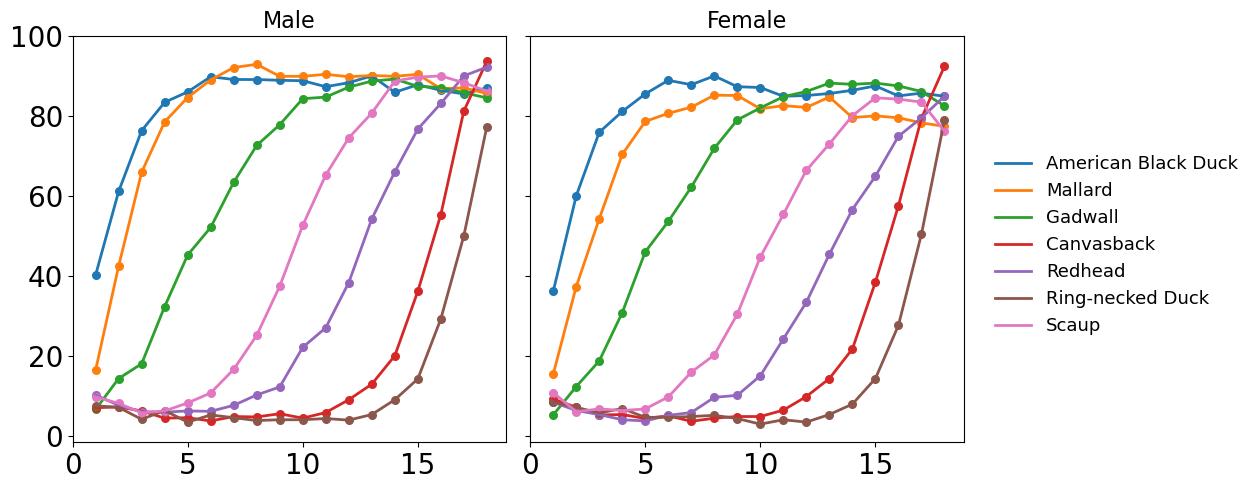

In [60]:
# Male and female on two plots
# With correction

def dict_to_df(prob_dict, label):
    return pd.DataFrame([
        {"time": t + 1, "species": species, "probability": prob * 100, "type": label}  # Multiply by 100 here
        for species, probs in prob_dict.items()
        for t, prob in enumerate(probs)
    ])

# Combine data
df_male = dict_to_df(prob_match_male_dict, "Male")
df_female = dict_to_df(prob_match_female_dict, "Female")
df_all = pd.concat([df_male, df_female])

# Legend order
priority_order = ['American Black Duck', 'Mallard', 'Gadwall']
# priority_order = []   # If compare dabbling and diving duck, comment out the line above and uncomment this line
remaining = sorted([sp for sp in prob_match_male_dict if sp not in priority_order])
legend_order = priority_order + remaining

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for ax, match_type in zip(axes, ['Male', 'Female']):
    df = df_all[df_all["type"] == match_type]
    for i, species in enumerate(legend_order):
        group = df[df["species"] == species]
        ax.plot(group["time"], group["probability"], label=species if match_type == 'Male' else None, linewidth=2)
        ax.scatter(group["time"], group["probability"], s=30)

    # X and Y ticks
    ax.set_xticks([0, 5, 10, 15])
    ax.set_xticklabels([0, 5, 10, 15], fontsize=20)
    ax.set_yticks([0, 20, 40, 60, 80, 100])
    ax.set_yticklabels([0, 20, 40, 60, 80, 100], fontsize=20)

    ax.set_title(match_type, fontsize=16)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.grid(False)

# Shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc='center left', bbox_to_anchor=(0.82, 0.5),
    fontsize=13, frameon=False
)

plt.tight_layout(rect=[0, 0, 0.82, 1])
plt.show()


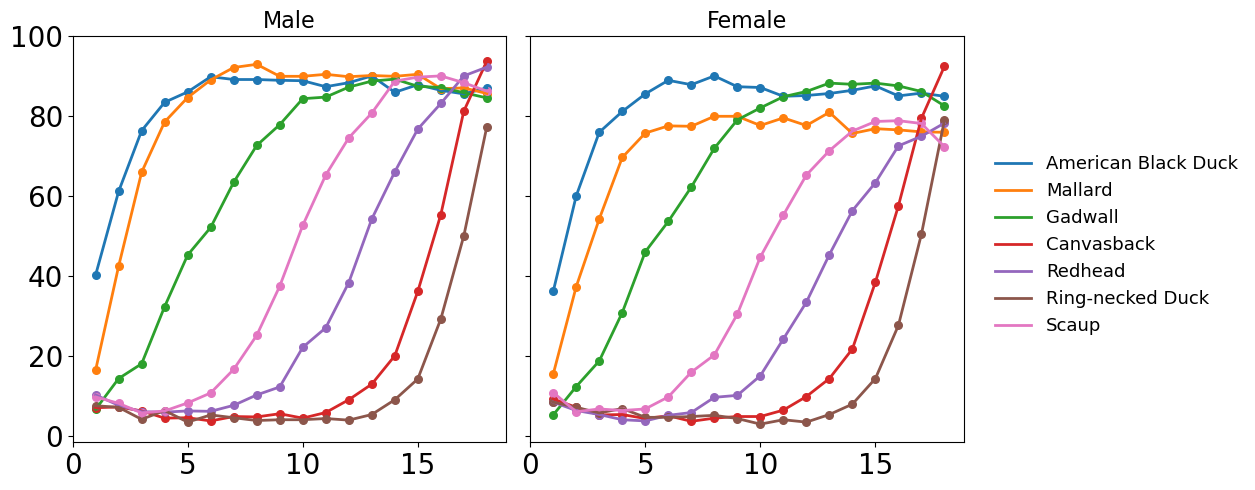

In [61]:
# Male and female on two plots
# Without correction

def dict_to_df(prob_dict, label):
    return pd.DataFrame([
        {"time": t + 1, "species": species, "probability": prob * 100, "type": label}  # Multiply by 100 here
        for species, probs in prob_dict.items()
        for t, prob in enumerate(probs)
    ])

# Combine data
df_male = dict_to_df(prob_male_uncorrected_dict, "Male")
df_female = dict_to_df(prob_female_uncorrected_dict, "Female")
df_all = pd.concat([df_male, df_female])

# Legend order
priority_order = ['American Black Duck', 'Mallard', 'Gadwall']
remaining = sorted([sp for sp in prob_match_male_dict if sp not in priority_order])
legend_order = priority_order + remaining

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for ax, match_type in zip(axes, ['Male', 'Female']):
    df = df_all[df_all["type"] == match_type]
    for i, species in enumerate(legend_order):
        group = df[df["species"] == species]
        ax.plot(group["time"], group["probability"], label=species if match_type == 'Male' else None, linewidth=2)
        ax.scatter(group["time"], group["probability"], s=30)

    # X and Y ticks
    ax.set_xticks([0, 5, 10, 15])
    ax.set_xticklabels([0, 5, 10, 15], fontsize=20)
    ax.set_yticks([0, 20, 40, 60, 80, 100])
    ax.set_yticklabels([0, 20, 40, 60, 80, 100], fontsize=20)

    ax.set_title(match_type, fontsize=16)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.grid(False)

# Shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc='center left', bbox_to_anchor=(0.82, 0.5),
    fontsize=13, frameon=False
)

plt.tight_layout(rect=[0, 0, 0.82, 1])
plt.show()


In [62]:
# Male and female on two side-by-side plots
# With correction

# Legend order (for the full model)
priority_order = ['American Black Duck', 'Mallard', 'Gadwall']
remaining = sorted([sp for sp in mean_male if sp not in priority_order])
legend_order = priority_order + remaining

# Legend order (for the reduced model)
legend_order = ['Dabbling Duck', 'Diving Duck']

# Color map
color_map = plt.get_cmap("tab10")
species_colors = {species: color_map(i % 10) for i, species in enumerate(legend_order)}

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
week_range = np.arange(1, len(next(iter(mean_male.values()))) + 1)

for ax, match_type in zip(axes, ['Male', 'Female']):
    for species in legend_order:
        color = species_colors[species]

        if match_type == 'Male':
            mean = mean_male[species] * 100
            lower = ci_male_lower[species] * 100
            upper = ci_male_upper[species] * 100
        else:
            mean = mean_female[species] * 100
            lower = ci_female_lower[species] * 100
            upper = ci_female_upper[species] * 100

        # Plot mean line
        ax.plot(week_range, mean, color=color, label=species if match_type == 'Male' else None, linewidth=2)
        ax.scatter(week_range, mean, color=color, s=30)

        # Plot error band
        ax.fill_between(week_range, lower, upper, color=color, alpha=0.2)

    # Ticks and labels
    ax.set_xticks([0, 5, 10, 15])
    ax.set_xticklabels([0, 5, 10, 15], fontsize=20)
    ax.set_yticks([0, 20, 40, 60, 80, 100])
    ax.set_yticklabels([0, 20, 40, 60, 80, 100], fontsize=20)

    ax.set_title(match_type, fontsize=16)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.grid(False)

# Shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc='center left', bbox_to_anchor=(0.82, 0.5),
    fontsize=13, frameon=False
)

plt.tight_layout(rect=[0, 0, 0.82, 1])
plt.show()


NameError: name 'mean_male' is not defined

In [63]:
# Male and female on the same plot
# With correciton
prob_match_male_dict = mean_male
prob_match_female_dict = mean_female

def dict_to_df(prob_dict, label):
    return pd.DataFrame([
        {"time": t + 1, "species": species, "probability": prob * 100, "type": label}
        for species, probs in prob_dict.items()
        for t, prob in enumerate(probs)
    ])

# Combine data
df_male = dict_to_df(prob_match_male_dict, "Male")
df_female = dict_to_df(prob_match_female_dict, "Female")
df_all = pd.concat([df_male, df_female])

# Legend order
priority_order = ['American Black Duck', 'Mallard', 'Gadwall']
remaining = sorted([sp for sp in prob_match_male_dict if sp not in priority_order])
legend_order = priority_order + remaining


species_list = legend_order
color_map = plt.get_cmap("tab10")
species_colors = {species: color_map(i % 10) for i, species in enumerate(species_list)}

# Plot
plt.figure(figsize=(15, 5))
for species in species_list:
    color = species_colors[species]

    # Male: solid
    male_group = df_all[(df_all["species"] == species) & (df_all["type"] == "Male")]
    plt.plot(
        male_group["time"], male_group["probability"],
        label=species, color=color, linewidth=2
    )
    plt.scatter(male_group["time"], male_group["probability"], s=30, color=color)

    # Female: dashed
    female_group = df_all[(df_all["species"] == species) & (df_all["type"] == "Female")]
    plt.plot(
        female_group["time"], female_group["probability"],
        linestyle='dashed', linewidth=2, color=color
    )
    plt.scatter(female_group["time"], female_group["probability"], s=30, color=color)

# Ticks and style
plt.xticks([0, 5, 10, 15], fontsize=20)
plt.yticks([0, 20, 40, 60, 80, 100], fontsize=20)
plt.xlabel("")
plt.ylabel("")
plt.grid(False)

# Legend
plt.legend(
    loc='center left', bbox_to_anchor=(0.99, 0.5),
    fontsize=13, frameon=False
)

plt.tight_layout(rect=[0, 0, 0.82, 1])
plt.show()


NameError: name 'mean_male' is not defined